## 1. Imports & Setup

In [1]:
# Hapus tanda # di baris ini pada kode kamu:
!pip install -q optuna lightgbm catboost xgboost scikit-learn

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Install & Import
# ─────────────────────────────────────────────────────────────────────────────
# Install required packages (uncomment if needed in Colab)
# !pip install -q optuna lightgbm catboost xgboost scikit-learn

import warnings
warnings.filterwarnings('ignore')
import os

# Core
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Deteksi Spek Lokal (Intel i7 Gen 13)
TOTAL_THREADS = os.cpu_count() # Biasanya 16 atau 20 threads pada i7 Gen 13
MAX_LOCAL_JOBS = max(1, TOTAL_THREADS - 2) # Sisakan 2 thread agar Windows tidak freeze

print('=' * 60)
print(f'💻 KONFIGURASI LOKAL INTEL i7 GEN 13 detected:')
print(f'   Total CPU Threads Tersedia : {TOTAL_THREADS}')
print(f'   Kapasitas Maksimal Digunakan: {MAX_LOCAL_JOBS} Threads (Aman & Ngebut)')
print('=' * 60)

# Visualization
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display

# Stats
from scipy import stats
from scipy.stats import chi2_contingency

# Sklearn
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

# Gradient Boosting Models
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Hyperparameter Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ──────────────────────────────────────────
# GLOBAL STYLE SETTINGS
# ──────────────────────────────────────────
COLORS = {
    'Graduate': '#00c9a7',
    'Dropout':  '#ff6b6b',
    'Enrolled': '#ffd166',
    'accent':   '#845ef7',
    'blue':     '#4dabf7',
    'bg':       '#0f1117',
    'panel':    '#1a1d27',
}
PALETTE = [COLORS['Graduate'], COLORS['Dropout'], COLORS['Enrolled']]
TARGET_ORDER = ['Graduate', 'Dropout', 'Enrolled']

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],
    'axes.facecolor':   COLORS['panel'],
    'axes.edgecolor':   '#3a3d4a',
    'axes.labelcolor':  '#e0e0e0',
    'axes.titlecolor':  '#ffffff',
    'xtick.color':      '#b0b0b0',
    'ytick.color':      '#b0b0b0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d3a',
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
    'font.size':        10,
    'axes.titlesize':   12,
    'axes.labelsize':   10,
})

SEED = 42
np.random.seed(SEED)

print('✅ All libraries imported successfully!')
print(f'   XGBoost  : {xgb.__version__}')
print(f'   LightGBM : {lgb.__version__}')
print(f'   Optuna   : {optuna.__version__}')

💻 KONFIGURASI LOKAL INTEL i7 GEN 13 detected:
   Total CPU Threads Tersedia : 20
   Kapasitas Maksimal Digunakan: 18 Threads (Aman & Ngebut)
✅ All libraries imported successfully!
   XGBoost  : 2.1.4
   LightGBM : 4.6.0
   Optuna   : 4.9.0


# 2. Load Data & Initial Snapshot

In [3]:
try:
    # Langsung membaca dari folder aktif di komputer kamu
    train = pd.read_csv('train.csv')
    test  = pd.read_csv('test.csv')
    sub   = pd.read_csv('sample_submission.csv')
    print('✅ DATASET BERHASIL DI-LOAD DI MESIN LOKAL')
except FileNotFoundError:
    print('❌ File .csv tidak ditemukan! Pastikan train.csv diletakkan di folder yang sama dengan skrip ini.')

print('=' * 60)
print('   DATASET LOADED SUCCESSFULLY')
print('=' * 60)
print(f'   Train shape : {train.shape}  ({train.shape[0]:,} rows × {train.shape[1]} cols)')
print(f'   Test shape  : {test.shape}  ({test.shape[0]:,} rows × {test.shape[1]} cols)')
print(f'   Sample sub  : {sub.shape}')
print()
print('   TARGET DISTRIBUTION (Train):')
vc = train['Target'].value_counts()
for cls, cnt in vc.items():
    print(f'    {cls:<12}: {cnt:>6,}  ({cnt/len(train)*100:.1f}%)')

✅ DATASET BERHASIL DI-LOAD DI MESIN LOKAL
   DATASET LOADED SUCCESSFULLY
   Train shape : (76518, 38)  (76,518 rows × 38 cols)
   Test shape  : (51012, 37)  (51,012 rows × 37 cols)
   Sample sub  : (51012, 2)

   TARGET DISTRIBUTION (Train):
    Graduate    : 36,282  (47.4%)
    Dropout     : 25,296  (33.1%)
    Enrolled    : 14,940  (19.5%)


In [4]:
print('📌 FIRST 5 ROWS OF TRAINING DATA:')
print('-' * 80)
display(train.head())

📌 FIRST 5 ROWS OF TRAINING DATA:
--------------------------------------------------------------------------------


,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0,1,1,1,9238,1,1,126.0000,1,1,19,5,5,122.6000,0,0,0,1,0,1,18,0,0,6,6,6,14.5000,0,0,6,7,6,12.4286,0,11.1000,0.6000,2.0200,Graduate
1,1,1,17,1,9238,1,1,125.0000,1,19,19,9,9,119.8000,1,0,0,1,0,0,18,0,0,6,8,4,11.6000,0,0,6,9,0,0.0000,0,11.1000,0.6000,2.0200,Dropout
2,2,1,17,2,9254,1,1,137.0000,1,3,19,2,3,144.7000,0,0,0,1,1,0,18,0,0,6,0,0,0.0000,0,0,6,0,0,0.0000,0,16.2000,0.3000,-0.9200,Dropout
3,3,1,1,3,9500,1,1,131.0000,1,19,3,3,2,126.1000,1,0,0,1,0,1,18,0,0,7,9,7,12.5913,0,0,8,11,7,12.8200,0,11.1000,0.6000,2.0200,Enrolled
4,4,1,1,2,9500,1,1,132.0000,1,19,37,4,9,120.1000,1,0,0,1,0,0,18,0,0,7,12,6,12.9333,0,0,7,12,6,12.9333,0,7.6000,2.6000,0.3200,Graduate


In [5]:
print('\n📌 DATA TYPES & NULLS:')
print('-' * 80)
dtype_info = pd.DataFrame({
    'dtype':    train.dtypes,
    'nulls':    train.isnull().sum(),
    'null_%':   (train.isnull().sum() / len(train) * 100).round(2),
    'unique':   train.nunique(),
    'min':      train.min(numeric_only=True),
    'max':      train.max(numeric_only=True),
    'mean':     train.mean(numeric_only=True).round(3),
    'std':      train.std(numeric_only=True).round(3),
})
display(dtype_info)


📌 DATA TYPES & NULLS:
--------------------------------------------------------------------------------


,dtype,nulls,null_%,unique,min,max,mean,std
Admission grade,float64,0,0.0000,668,95.0000,190.0000,125.3640,12.5620
Age at enrollment,int64,0,0.0000,46,17.0000,70.0000,22.2790,6.8890
Application mode,int64,0,0.0000,22,1.0000,53.0000,16.0540,16.6820
Application order,int64,0,0.0000,8,0.0000,9.0000,1.6440,1.2300
Course,int64,0,0.0000,19,33.0000,9991.0000,9001.2860,1803.4390
Curricular units 1st sem (approved),int64,0,0.0000,23,0.0000,26.0000,4.1790,2.6880
Curricular units 1st sem (credited),int64,0,0.0000,21,0.0000,20.0000,0.1890,1.1750
Curricular units 1st sem (enrolled),int64,0,0.0000,24,0.0000,26.0000,5.8920,1.6720
Curricular units 1st sem (evaluations),int64,0,0.0000,36,0.0000,45.0000,7.3520,3.5080
Curricular units 1st sem (grade),float64,0,0.0000,1206,0.0000,18.8750,9.9960,5.2640


In [6]:
print('\n📌 DESCRIPTIVE STATISTICS:')
print('-' * 80)
display(train.describe())


📌 DESCRIPTIVE STATISTICS:
--------------------------------------------------------------------------------


,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000
mean,38258.5000,1.1119,16.0544,1.6444,9001.2864,0.9153,3.6588,132.3788,1.2266,19.8376,23.4251,8.5832,8.8822,125.3640,0.5693,0.0037,0.0714,0.8936,0.3158,0.2474,22.2787,0.0066,0.1889,5.8915,7.3524,4.1785,9.9959,0.0580,0.1371,5.9334,7.2345,4.0072,9.6261,0.0624,11.5203,1.2282,-0.0809
std,22088.9883,0.4417,16.6823,1.2296,1803.4385,0.2784,8.6238,10.9953,3.3922,15.3995,14.9212,17.4716,16.8039,12.5623,0.4952,0.0610,0.2575,0.3083,0.4648,0.4315,6.8892,0.0811,1.1753,1.6718,3.5083,2.6880,5.2642,0.4085,0.9338,1.6272,3.5030,2.7730,5.5460,0.4621,2.6534,1.3988,2.2514
min,0.0000,1.0000,1.0000,0.0000,33.0000,0.0000,1.0000,95.0000,1.0000,1.0000,1.0000,0.0000,0.0000,95.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,17.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,7.6000,-0.8000,-4.0600
25%,19129.2500,1.0000,1.0000,1.0000,9119.0000,1.0000,1.0000,125.0000,1.0000,1.0000,4.0000,4.0000,5.0000,118.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,18.0000,0.0000,0.0000,5.0000,6.0000,2.0000,10.6667,0.0000,0.0000,5.0000,6.0000,1.0000,10.0000,0.0000,9.4000,0.3000,-1.7000
50%,38258.5000,1.0000,17.0000,1.0000,9254.0000,1.0000,1.0000,133.1000,1.0000,19.0000,19.0000,7.0000,7.0000,124.6000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,19.0000,0.0000,0.0000,6.0000,7.0000,5.0000,12.1667,0.0000,0.0000,6.0000,7.0000,5.0000,12.1429,0.0000,11.1000,1.4000,0.3200
75%,57387.7500,1.0000,39.0000,2.0000,9670.0000,1.0000,1.0000,140.0000,1.0000,37.0000,37.0000,9.0000,9.0000,132.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,23.0000,0.0000,0.0000,6.0000,9.0000,6.0000,13.3143,0.0000,0.0000,6.0000,9.0000,6.0000,13.2440,0.0000,12.7000,2.6000,1.7900
max,76517.0000,6.0000,53.0000,9.0000,9991.0000,1.0000,43.0000,190.0000,109.0000,44.0000,44.0000,194.0000,195.0000,190.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,70.0000,1.0000,20.0000,26.0000,45.0000,26.0000,18.8750,12.0000,19.0000,23.0000,33.0000,20.0000,18.0000,12.0000,16.2000,3.7000,3.5100


## 3. Data Quality Assessment

In [7]:
print('=' * 60)
print('  DATA QUALITY AUDIT')
print('=' * 60)

  DATA QUALITY AUDIT


In [8]:
total_missing = train.isnull().sum().sum()
print(f'\n  1. Missing Values  : {total_missing} (✅ None!)' if total_missing == 0
      else f'\n  1. Missing Values  : {total_missing} ⚠️')


  1. Missing Values  : 0 (✅ None!)


In [9]:
dups = train.duplicated().sum()
print(f'  2. Duplicate Rows  : {dups} (✅ None!)' if dups == 0
      else f'  2. Duplicate Rows  : {dups} ⚠️')

  2. Duplicate Rows  : 0 (✅ None!)


In [10]:
print('\n  3. Class Imbalance Check:')
vc = train['Target'].value_counts()
majority = vc.max()
minority = vc.min()
ratio    = majority / minority
print(f'     Majority class : {vc.idxmax()} ({majority:,})')
print(f'     Minority class : {vc.idxmin()} ({minority:,})')
print(f'     Imbalance ratio: {ratio:.2f}x  '
      + ('(⚠️ Moderate imbalance — monitor)' if ratio > 2 else '(✅ Acceptable)'))


  3. Class Imbalance Check:
     Majority class : Graduate (36,282)
     Minority class : Enrolled (14,940)
     Imbalance ratio: 2.43x  (⚠️ Moderate imbalance — monitor)


In [11]:
cont_feats = ['Admission grade', 'Previous qualification (grade)',
              'Age at enrollment', 'Curricular units 1st sem (grade)',
              'Curricular units 2nd sem (grade)', 'Unemployment rate',
              'Inflation rate', 'GDP']
print('\n  4. Outlier Percentage (IQR method):')
for c in cont_feats:
    Q1, Q3 = train[c].quantile(0.25), train[c].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((train[c] < Q1 - 1.5*IQR) | (train[c] > Q3 + 1.5*IQR)).sum()
    flag = '⚠️' if n_out/len(train) > 0.05 else '✅'
    print(f'     {c:<45}: {n_out:>5,} rows ({n_out/len(train)*100:.1f}%) {flag}')


  4. Outlier Percentage (IQR method):
     Admission grade                              : 2,577 rows (3.4%) ✅
     Previous qualification (grade)               : 1,364 rows (1.8%) ✅
     Age at enrollment                            : 8,935 rows (11.7%) ⚠️
     Curricular units 1st sem (grade)             : 16,059 rows (21.0%) ⚠️
     Curricular units 2nd sem (grade)             : 18,482 rows (24.2%) ⚠️
     Unemployment rate                            :     0 rows (0.0%) ✅
     Inflation rate                               :     0 rows (0.0%) ✅
     GDP                                          :     0 rows (0.0%) ✅


In [12]:
print('\n  5. Train vs Test Feature Distributions (sample):')
for c in ['Age at enrollment', 'Admission grade', 'Unemployment rate']:
    t_mean = train[c].mean()
    te_mean = test[c].mean()
    shift_pct = abs(t_mean - te_mean) / (abs(t_mean) + 1e-9) * 100
    flag = '⚠️ Distribution Shift!' if shift_pct > 5 else '✅'
    print(f'     {c:<45}: train={t_mean:.2f} | test={te_mean:.2f} | shift={shift_pct:.1f}% {flag}')


  5. Train vs Test Feature Distributions (sample):
     Age at enrollment                            : train=22.28 | test=22.21 | shift=0.3% ✅
     Admission grade                              : train=125.36 | test=125.42 | shift=0.0% ✅
     Unemployment rate                            : train=11.52 | test=11.52 | shift=0.0% ✅


# 4. EDA — Visualizations (Pre-Processing)

In [13]:
fig = plt.figure(figsize=(20, 14), facecolor=COLORS['bg'])
fig.suptitle('📊  Academic Success Dataset — Overview Dashboard (Pre-Processing)',
             fontsize=20, color='white', fontweight='bold', y=0.99)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.6, wspace=0.45)

<Figure size 2000x1400 with 0 Axes>

In [14]:
kpi_data = [
    ('Training Rows',  f'{len(train):,}',    '#845ef7'),
    ('Test Rows',      f'{len(test):,}',     '#4dabf7'),
    ('Features',       '36',                '#00c9a7'),
    ('Target Classes', '3',                 '#ffd166'),
    ('Missing Values', '0 ✓',              '#00c9a7'),
    ('Duplicates',     '0 ✓',              '#00c9a7'),
    ('Train Accuracy\nBaseline', '47.5%',  '#ff6b6b'),
    ('Imbalance\nRatio', '2.43x',          '#ffd166'),
]
positions = [(0,0),(0,1),(0,2),(0,3),(1,0),(1,1),(1,2),(1,3)]
for (r,c_idx), (label, value, color) in zip(positions, kpi_data):
    ax = fig.add_subplot(gs[r, c_idx])
    ax.set_facecolor('#1a1d27')
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2.5)
    ax.text(0.5, 0.62, value, transform=ax.transAxes,
            ha='center', va='center', fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.22, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=9, color='#b0b0b0')
    ax.set_xticks([]); ax.set_yticks([])



In [15]:
ax_donut = fig.add_subplot(gs[2, 0:2])
ax_donut.set_facecolor(COLORS['panel'])
target_counts = train['Target'].value_counts().reindex(TARGET_ORDER)
wedges, texts, autotexts = ax_donut.pie(
    target_counts.values,
    labels=TARGET_ORDER,
    autopct='%1.1f%%',
    colors=PALETTE,
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor=COLORS['bg'], linewidth=2),
    textprops={'fontsize': 11, 'color': 'white'},
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold')
ax_donut.set_title('Target Class Distribution', pad=10, fontsize=13, color='white')
ax_donut.text(0, 0, f'{len(train):,}\nStudents', ha='center', va='center',
              fontsize=13, fontweight='bold', color='white')



Text(0, 0, '76,518\nStudents')

In [16]:
ax_tbl = fig.add_subplot(gs[2, 2:])
ax_tbl.set_facecolor(COLORS['panel'])
ax_tbl.axis('off')
cols_show = ['id', 'Age at enrollment', 'Course', 'Tuition fees up to date',
             'Scholarship holder', 'Curricular units 2nd sem (approved)',
             'Curricular units 2nd sem (grade)', 'Target']
tbl_data = train[cols_show].head(5)
col_labels = [c[:16]+'…' if len(c)>16 else c for c in tbl_data.columns]
table = ax_tbl.table(
    cellText=tbl_data.values, colLabels=col_labels,
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False); table.set_fontsize(8); table.scale(1, 1.8)
for (row, col_), cell in table.get_celld().items():
    cell.set_facecolor('#2a2d3a' if row == 0 else ('#1e2030' if row%2 else '#1a1d27'))
    cell.set_text_props(color='white'); cell.set_edgecolor('#3a3d4a')
ax_tbl.set_title('Sample Training Rows (Raw — Before Any Processing)', pad=10,
                 fontsize=11, color='white')

plt.savefig('fig01_overview_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Figure 1 saved: fig01_overview_dashboard.png')

<Figure size 640x480 with 0 Axes>

✅ Figure 1 saved: fig01_overview_dashboard.png


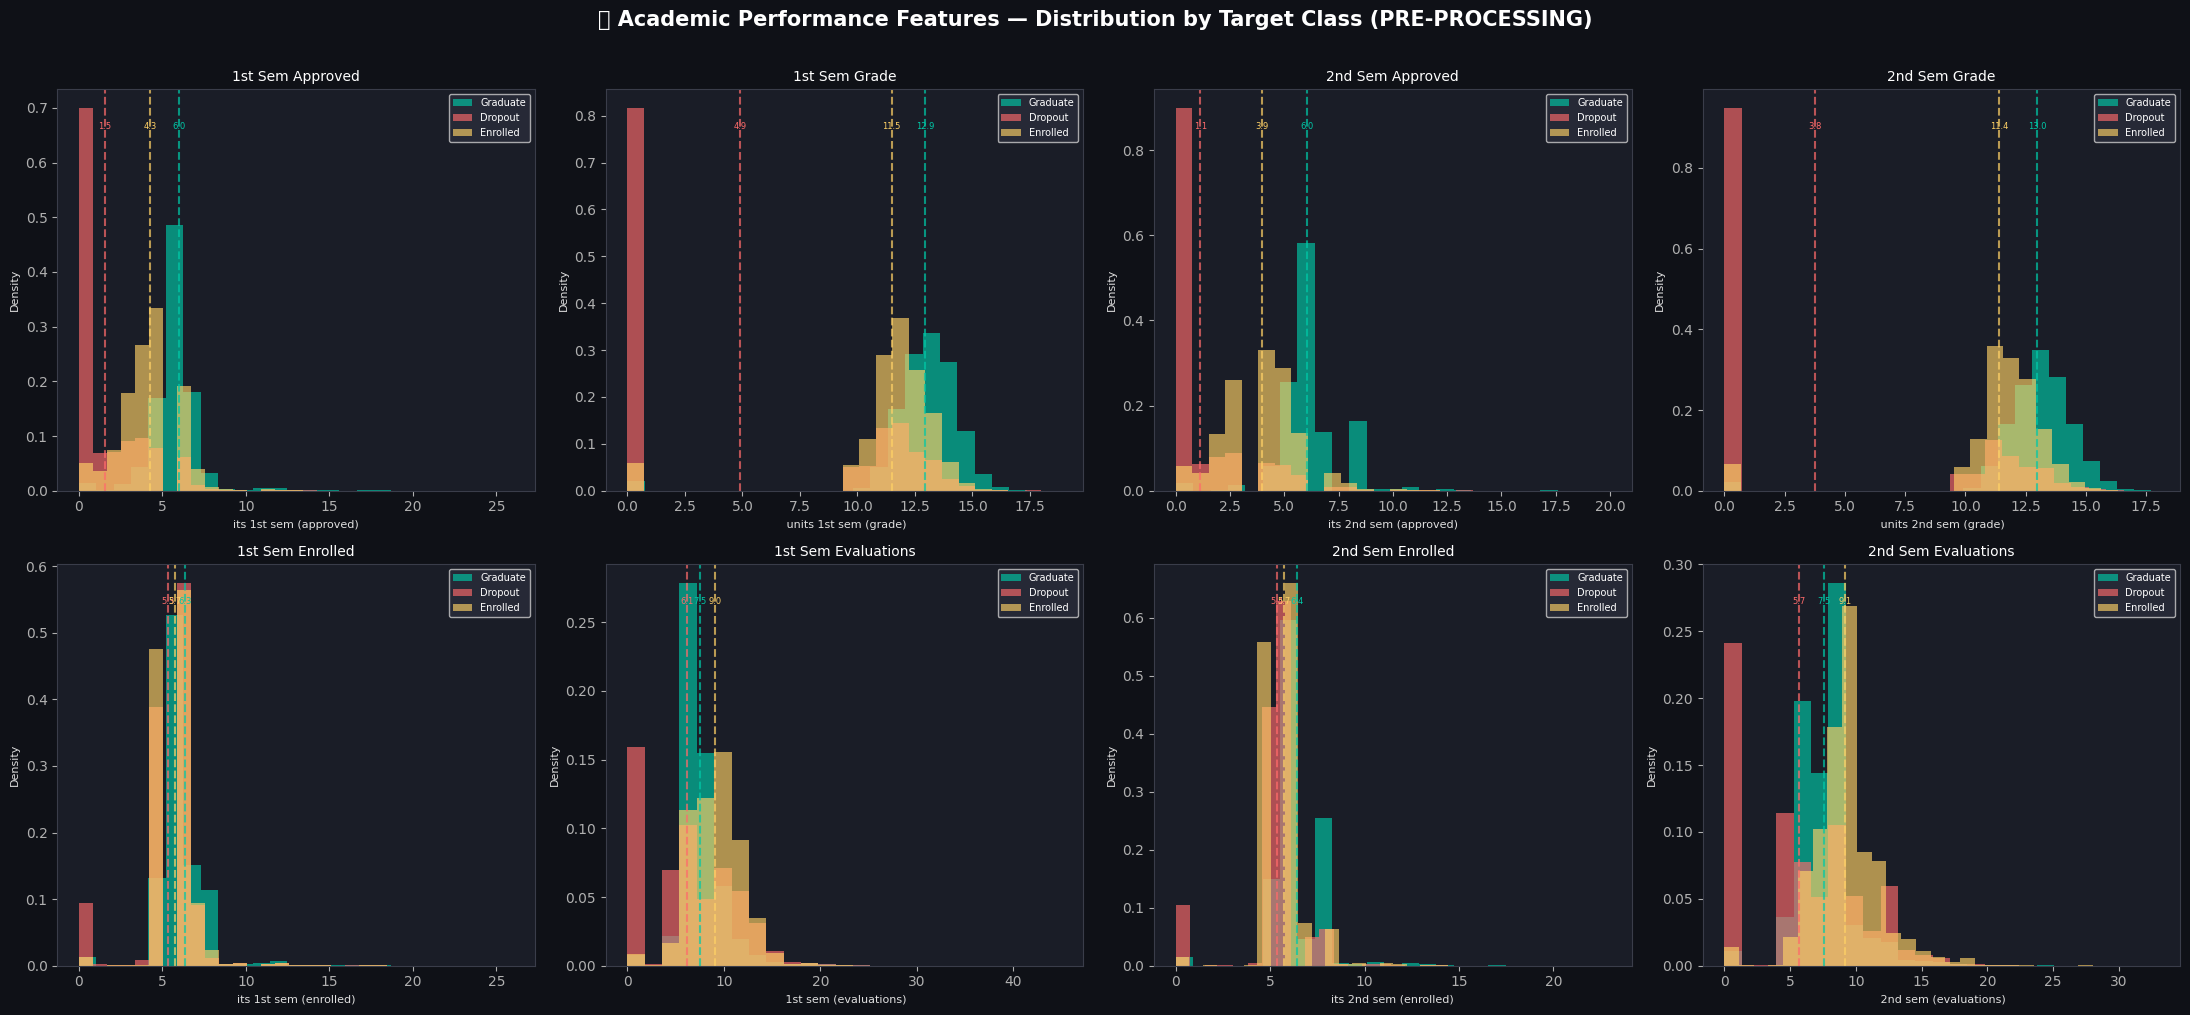

✅ Figure 2 saved: fig02_academic_performance.png

🔍 KEY INSIGHT: 2nd Semester Grade and Approved Units are the strongest
   discriminators. Graduates score much higher; Dropouts cluster near 0.


In [17]:
perf_features = [
    ('Curricular units 1st sem (approved)',     '1st Sem Approved'),
    ('Curricular units 1st sem (grade)',         '1st Sem Grade'),
    ('Curricular units 2nd sem (approved)',     '2nd Sem Approved'),
    ('Curricular units 2nd sem (grade)',         '2nd Sem Grade'),
    ('Curricular units 1st sem (enrolled)',      '1st Sem Enrolled'),
    ('Curricular units 1st sem (evaluations)', '1st Sem Evaluations'),
    ('Curricular units 2nd sem (enrolled)',     '2nd Sem Enrolled'),
    ('Curricular units 2nd sem (evaluations)', '2nd Sem Evaluations'),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10), facecolor=COLORS['bg'])
fig.suptitle('📐 Academic Performance Features — Distribution by Target Class (PRE-PROCESSING)',
             fontsize=15, color='white', fontweight='bold', y=1.01)

for ax, (col, title) in zip(axes.flatten(), perf_features):
    ax.set_facecolor(COLORS['panel'])
    for target, color in zip(TARGET_ORDER, PALETTE):
        subset = train[train['Target'] == target][col]
        ax.hist(subset, bins=25, alpha=0.65, color=color,
                label=target, density=True, edgecolor='none')
        ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_title(title, fontsize=10, color='white')
    ax.set_xlabel(col[-22:], fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7, facecolor='#2a2d3a', labelcolor='white', framealpha=0.8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#3a3d4a')
    # Annotate mean
    for target, color in zip(TARGET_ORDER, PALETTE):
        m = train[train['Target'] == target][col].mean()
        ax.text(m, ax.get_ylim()[1]*0.9, f'{m:.1f}',
                fontsize=6, color=color, ha='center')

plt.tight_layout()
plt.savefig('fig02_academic_performance.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Figure 2 saved: fig02_academic_performance.png')
print('\n🔍 KEY INSIGHT: 2nd Semester Grade and Approved Units are the strongest')
print('   discriminators. Graduates score much higher; Dropouts cluster near 0.')

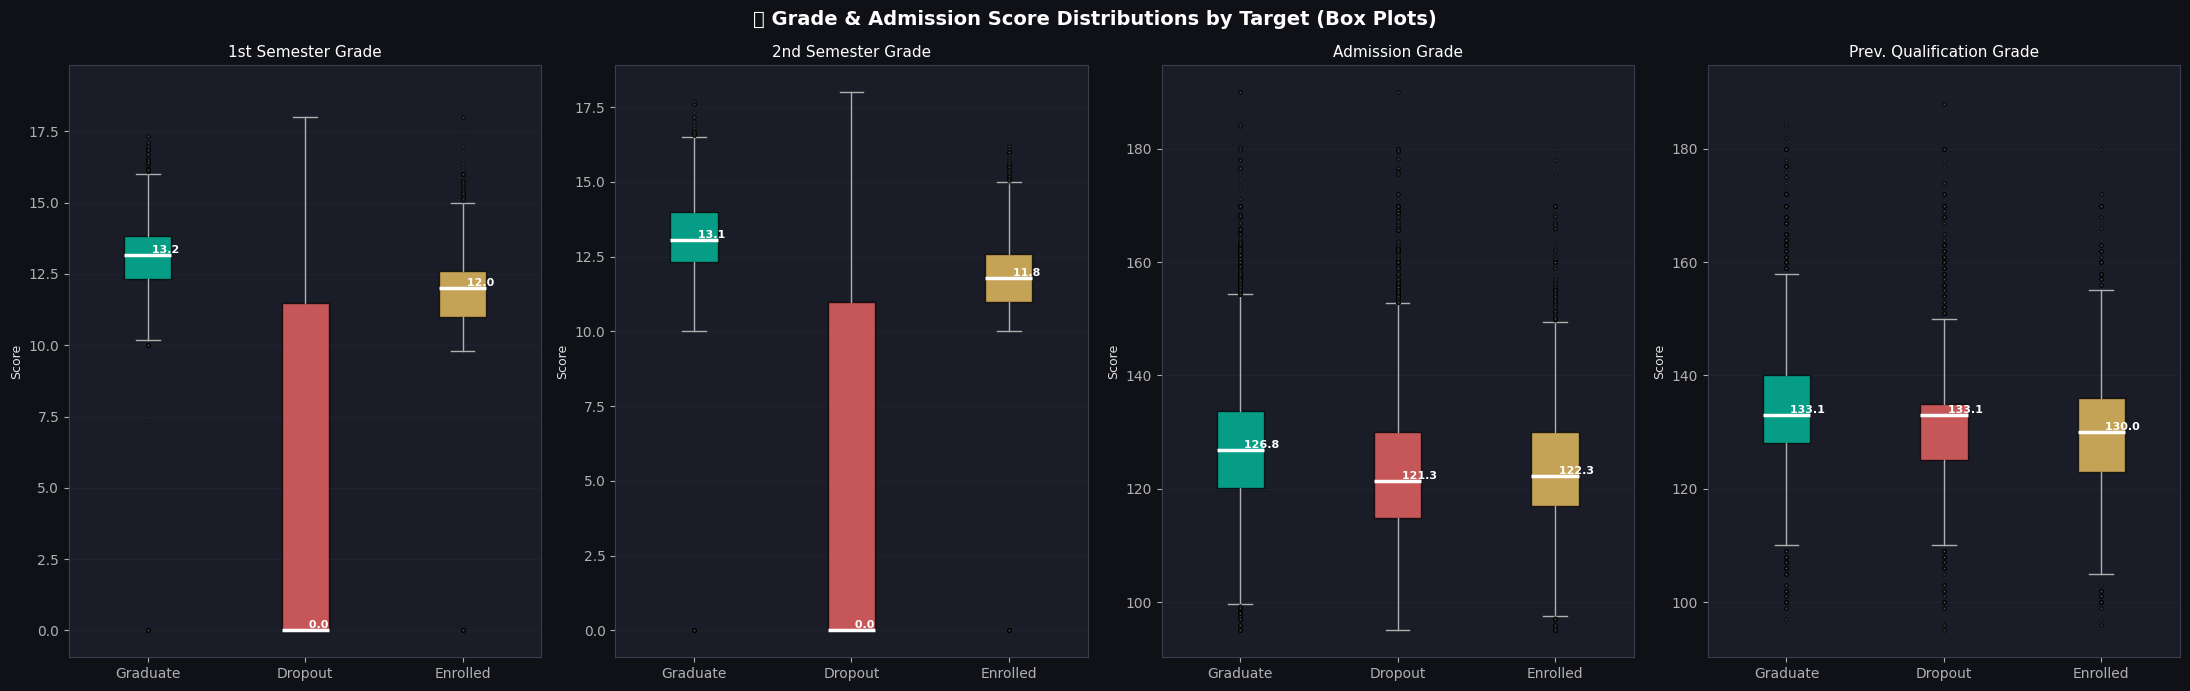

✅ Figure 3 saved: fig03_boxplots_grades.png


In [18]:
fig, axes = plt.subplots(1, 4, figsize=(22, 7), facecolor=COLORS['bg'])
fig.suptitle('📦 Grade & Admission Score Distributions by Target (Box Plots)',
             fontsize=14, color='white', fontweight='bold')

box_features = [
    ('Curricular units 1st sem (grade)', '1st Semester Grade'),
    ('Curricular units 2nd sem (grade)', '2nd Semester Grade'),
    ('Admission grade',                   'Admission Grade'),
    ('Previous qualification (grade)',    'Prev. Qualification Grade'),
]

for ax, (col, title) in zip(axes, box_features):
    ax.set_facecolor(COLORS['panel'])
    data_by_class = [train[train['Target'] == t][col].dropna().values
                     for t in TARGET_ORDER]
    bp = ax.boxplot(
        data_by_class,
        patch_artist=True,
        labels=TARGET_ORDER,
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(color='#b0b0b0'),
        capprops=dict(color='#b0b0b0'),
        flierprops=dict(marker='o', color='#555', alpha=0.3,
                        markersize=2, markerfacecolor='#555'),
    )
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    # Annotate medians
    for i, t in enumerate(TARGET_ORDER):
        med = np.median(train[train['Target'] == t][col].dropna())
        ax.text(i+1, med, f' {med:.1f}', color='white', fontsize=8,
                va='bottom', fontweight='bold')
    ax.set_title(title, fontsize=11, color='white')
    ax.set_ylabel('Score', fontsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#3a3d4a')
    ax.yaxis.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig03_boxplots_grades.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Figure 3 saved: fig03_boxplots_grades.png')

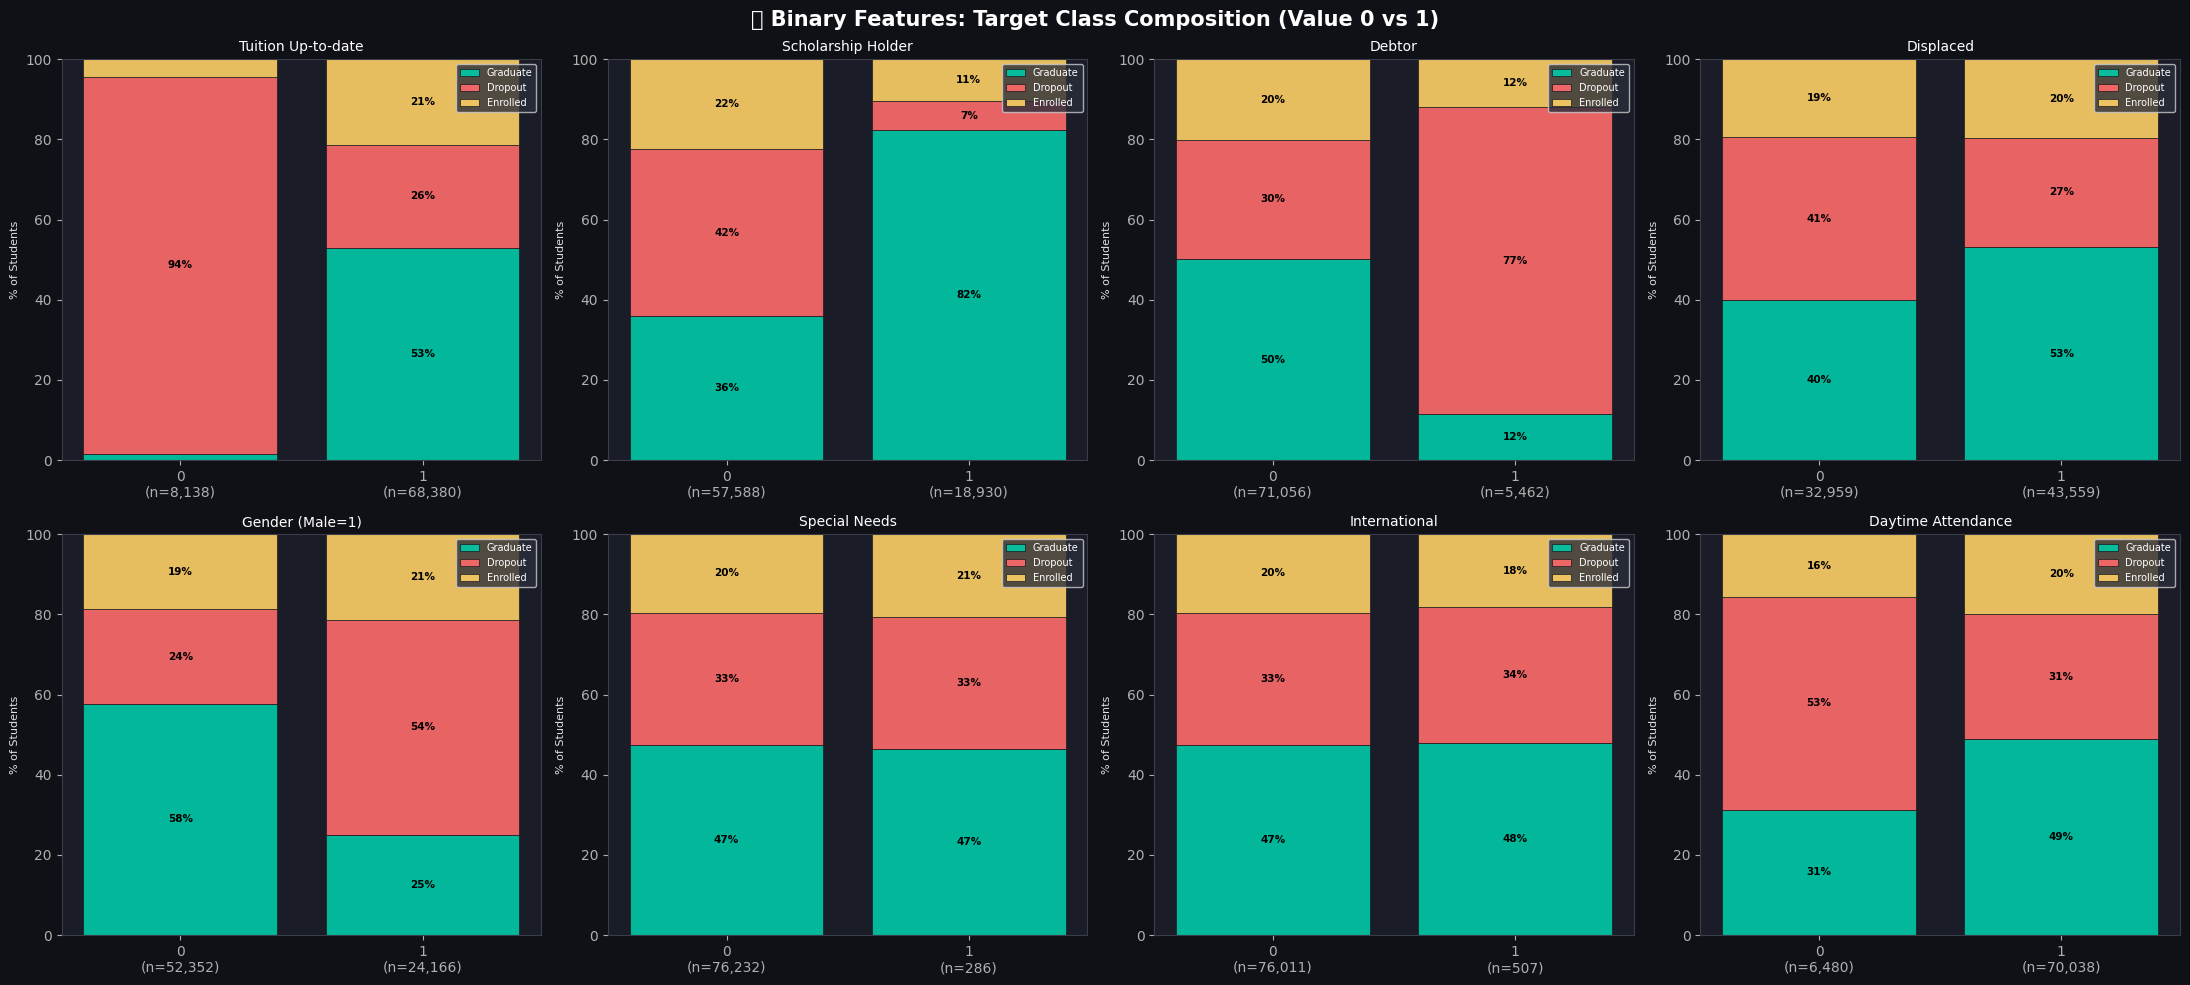

✅ Figure 4 saved: fig04_binary_stacked.png

🔍 KEY INSIGHT: Tuition fees up-to-date is EXTREMELY discriminative.
   Students with Tuition=0 drop out at ~75% rate. Scholarship holders
   graduate at higher rates. Debtor=1 strongly predicts Dropout.


In [19]:
binary_cols = ['Tuition fees up to date', 'Scholarship holder', 'Debtor',
               'Displaced', 'Gender', 'Educational special needs',
               'International', 'Daytime/evening attendance']
short_names  = ['Tuition Up-to-date', 'Scholarship Holder', 'Debtor',
                'Displaced', 'Gender (Male=1)', 'Special Needs',
                'International', 'Daytime Attendance']

fig, axes = plt.subplots(2, 4, figsize=(22, 10), facecolor=COLORS['bg'])
fig.suptitle('🔢 Binary Features: Target Class Composition (Value 0 vs 1)',
             fontsize=15, color='white', fontweight='bold')

for ax, col, name in zip(axes.flatten(), binary_cols, short_names):
    ax.set_facecolor(COLORS['panel'])
    ct = pd.crosstab(train[col], train['Target'], normalize='index').reindex(
        columns=TARGET_ORDER
    ).fillna(0)
    labels = [f'{v}\n(n={int((train[col]==v).sum()):,})'
              for v in ct.index]
    bottom = np.zeros(len(ct))
    for target, color in zip(TARGET_ORDER, PALETTE):
        vals = ct[target].values * 100
        ax.bar(labels, vals, bottom=bottom, color=color,
               label=target, edgecolor=COLORS['bg'], linewidth=0.5, alpha=0.9)
        for xi, (b, v) in enumerate(zip(bottom, vals)):
            if v > 7:
                ax.text(xi, b + v / 2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=7.5, color='black', fontweight='bold')
        bottom += vals
    ax.set_title(name, fontsize=10, color='white')
    ax.set_ylabel('% of Students', fontsize=8)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=7, facecolor='#2a2d3a', labelcolor='white',
              loc='upper right', framealpha=0.8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#3a3d4a')

plt.tight_layout()
plt.savefig('fig04_binary_stacked.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Figure 4 saved: fig04_binary_stacked.png')
print('\n🔍 KEY INSIGHT: Tuition fees up-to-date is EXTREMELY discriminative.')
print('   Students with Tuition=0 drop out at ~75% rate. Scholarship holders')
print('   graduate at higher rates. Debtor=1 strongly predicts Dropout.')

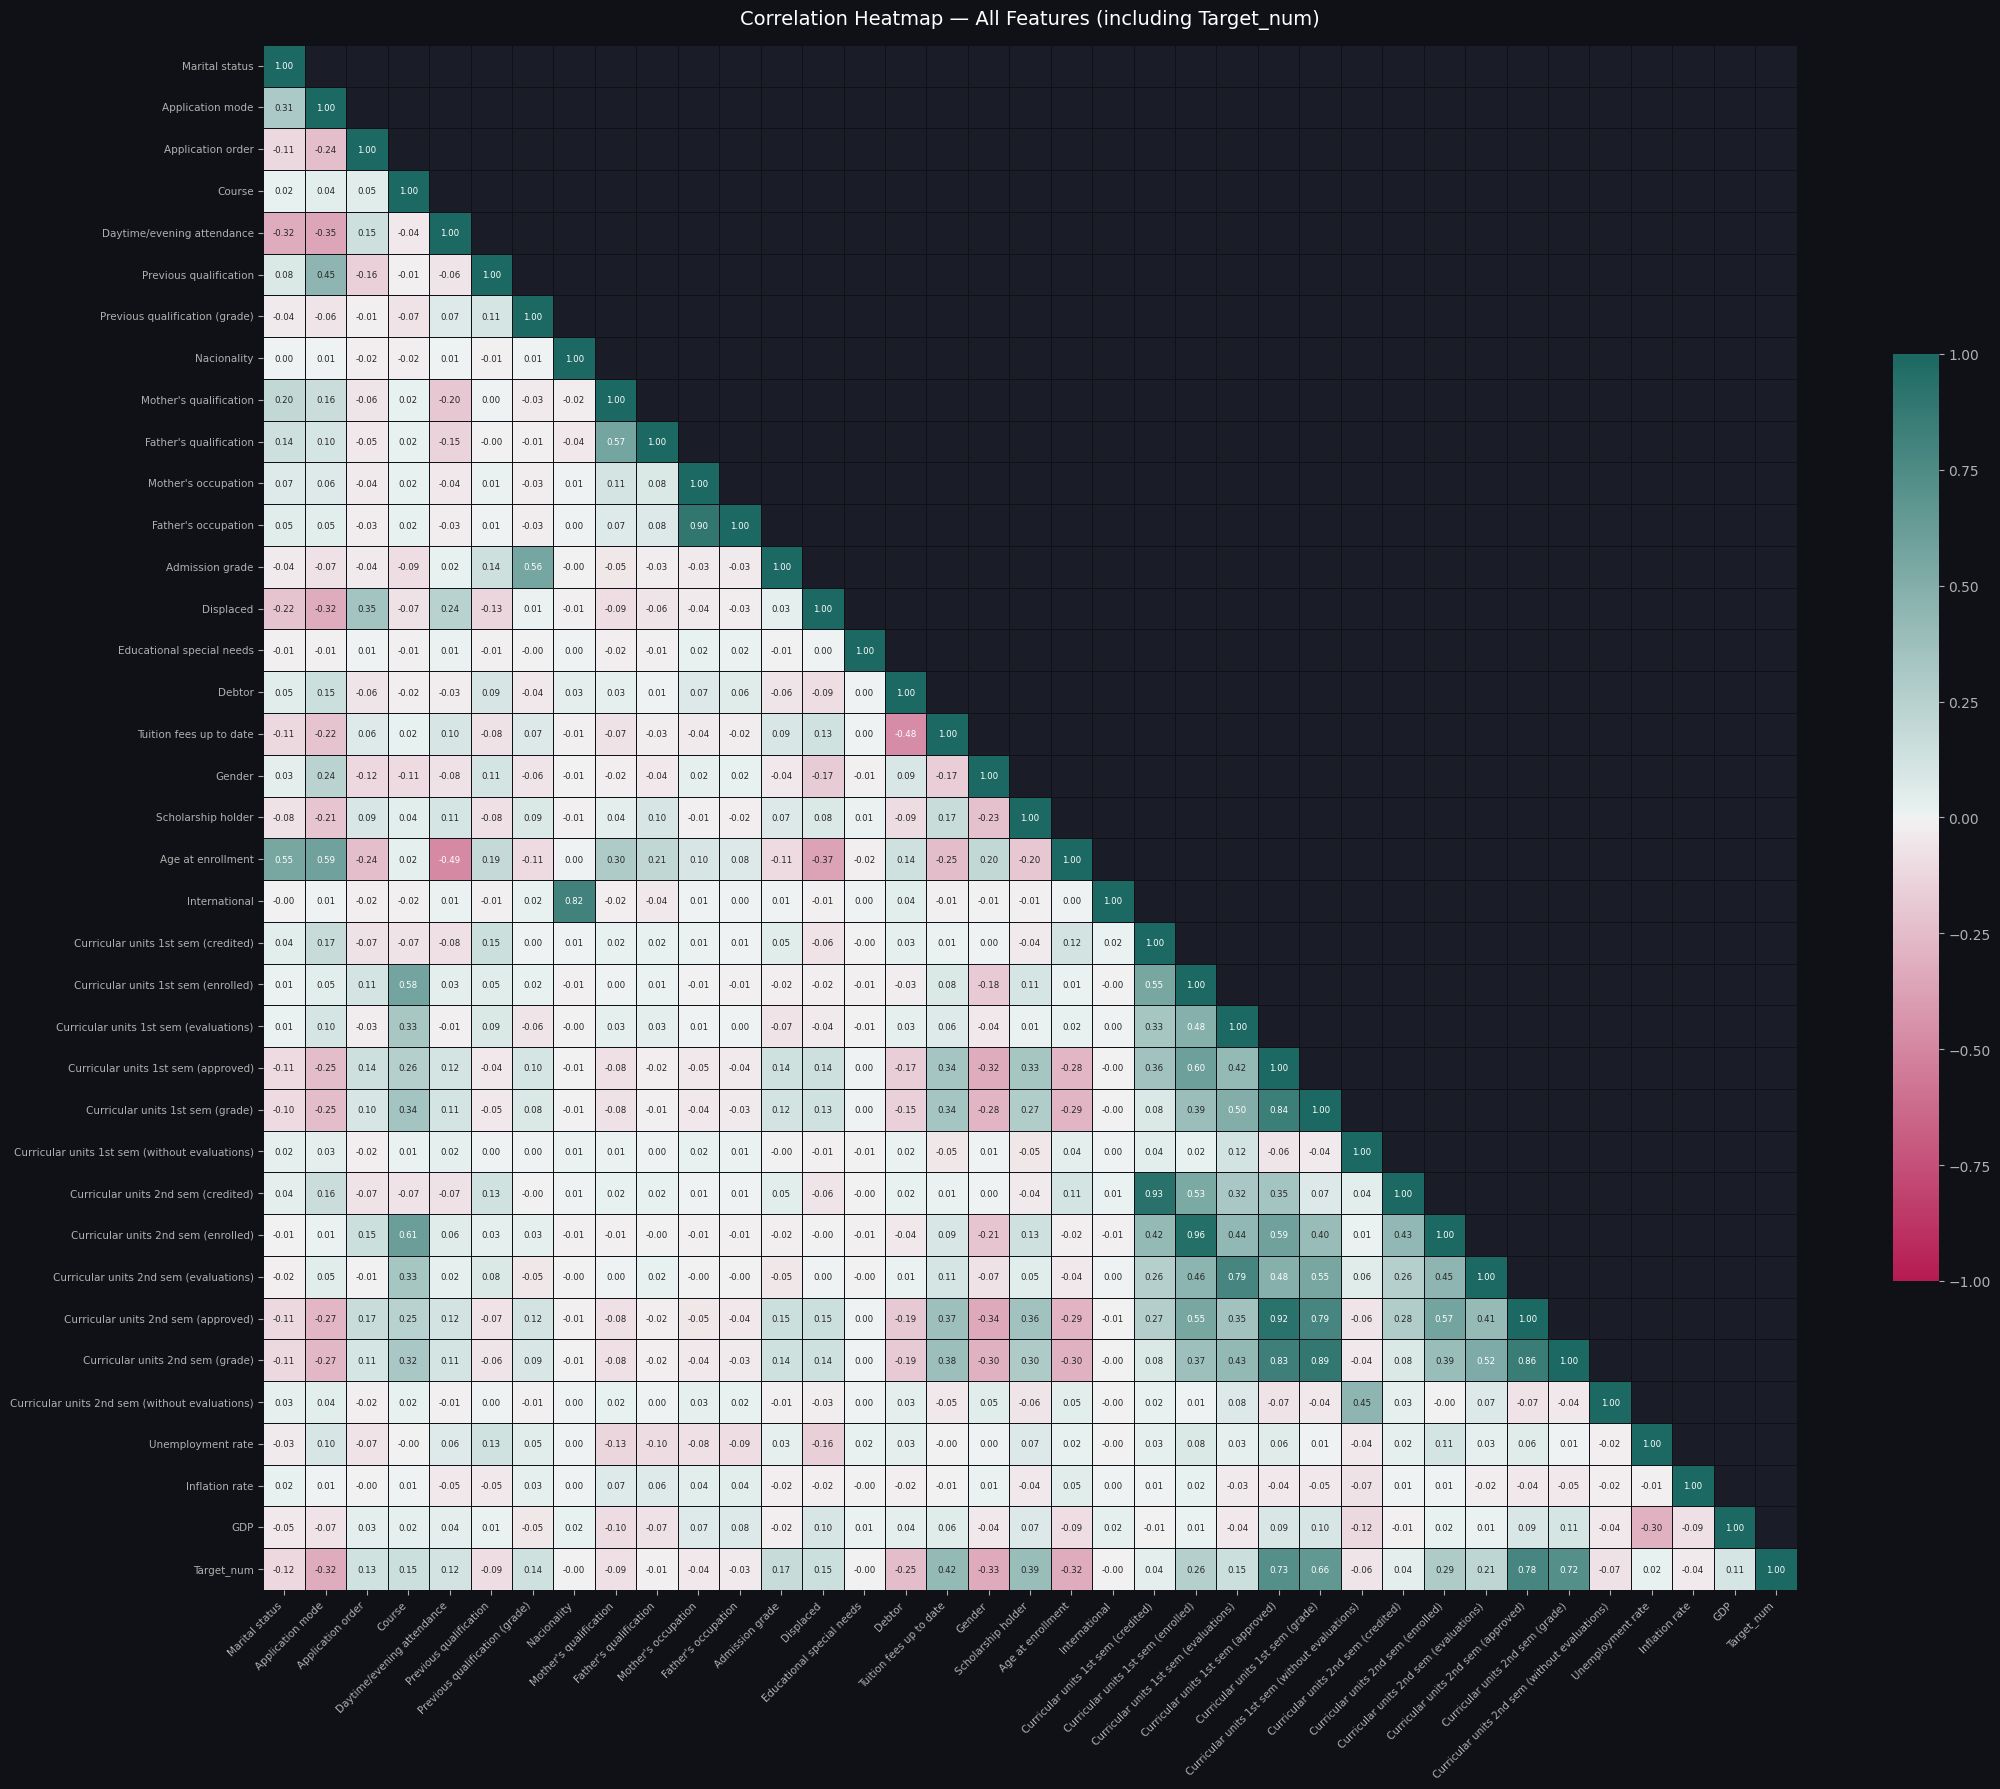

✅ Figure 5 saved: fig05_correlation_heatmap.png

🔍 TOP 10 FEATURES CORRELATED WITH TARGET_NUM:
   ↑ Curricular units 2nd sem (approved)               : r = +0.7815
   ↑ Curricular units 1st sem (approved)               : r = +0.7255
   ↑ Curricular units 2nd sem (grade)                  : r = +0.7190
   ↑ Curricular units 1st sem (grade)                  : r = +0.6614
   ↑ Tuition fees up to date                           : r = +0.4157
   ↑ Scholarship holder                                : r = +0.3941
   ↓ Gender                                            : r = -0.3302
   ↓ Application mode                                  : r = -0.3248
   ↓ Age at enrollment                                 : r = -0.3207
   ↑ Curricular units 2nd sem (enrolled)               : r = +0.2892


In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_enc = train.copy()
train_enc['Target_num'] = le.fit_transform(train['Target'])  # Dropout=0, Enrolled=1, Graduate=2
train_enc = train_enc.drop(columns=['id', 'Target'])
corr = train_enc.corr()

fig, ax = plt.subplots(figsize=(22, 18), facecolor=COLORS['bg'])
ax.set_facecolor(COLORS['panel'])
cmap = sns.diverging_palette(0, 180, s=90, l=40, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, cmap=cmap, center=0, annot=True,
    fmt='.2f', annot_kws={'size': 6.2}, linewidths=0.4,
    linecolor='#0f1117', ax=ax, cbar_kws={'shrink': 0.6},
    vmin=-1, vmax=1,
)
ax.set_title('Correlation Heatmap — All Features (including Target_num)',
             fontsize=14, color='white', pad=15)
plt.xticks(fontsize=7.5, rotation=45, ha='right')
plt.yticks(fontsize=7.5, rotation=0)
plt.tight_layout()
plt.savefig('fig05_correlation_heatmap.png', dpi=130, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Figure 5 saved: fig05_correlation_heatmap.png')

# Print top correlations with Target
print('\n🔍 TOP 10 FEATURES CORRELATED WITH TARGET_NUM:')
top_corr = corr['Target_num'].drop('Target_num').abs().sort_values(ascending=False)
for feat, val in top_corr.head(10).items():
    dir_sym = '↑' if corr['Target_num'][feat] > 0 else '↓'
    print(f'   {dir_sym} {feat:<50}: r = {corr["Target_num"][feat]:+.4f}')

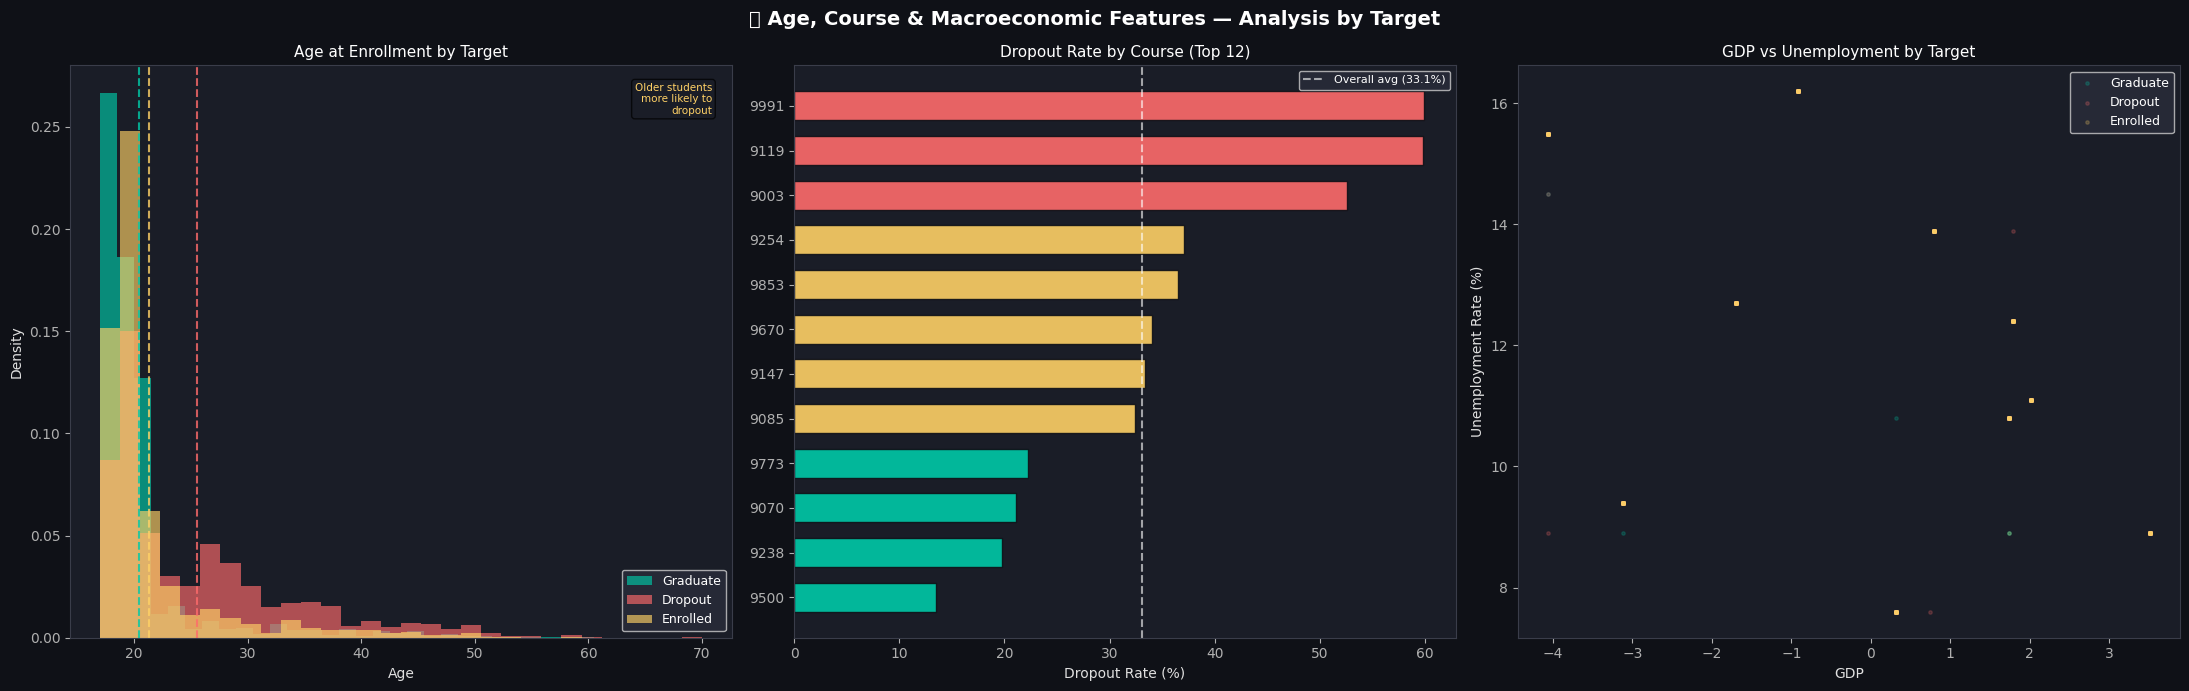

✅ Figure 6 saved: fig06_age_course_macro.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7), facecolor=COLORS['bg'])
fig.suptitle('🌍 Age, Course & Macroeconomic Features — Analysis by Target',
             fontsize=14, color='white', fontweight='bold')

# Plot 1: Age Distribution
ax = axes[0]
ax.set_facecolor(COLORS['panel'])
for target, color in zip(TARGET_ORDER, PALETTE):
    subset = train[train['Target'] == target]['Age at enrollment']
    ax.hist(subset, bins=30, alpha=0.65, color=color, label=target, density=True)
    ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=1.5, alpha=0.8)
ax.set_title('Age at Enrollment by Target', fontsize=11)
ax.set_xlabel('Age'); ax.set_ylabel('Density')
ax.legend(fontsize=9, facecolor='#2a2d3a', labelcolor='white')
ax.text(0.97, 0.97,
    f'Older students\nmore likely to\ndropout',
    transform=ax.transAxes, ha='right', va='top',
    fontsize=7.5, color='#ffd166',
    bbox=dict(boxstyle='round', facecolor='#1a1d27', alpha=0.7))
for spine in ax.spines.values(): spine.set_edgecolor('#3a3d4a')

# Plot 2: Course Dropout Rate
ax = axes[1]
ax.set_facecolor(COLORS['panel'])
top_courses = train['Course'].value_counts().head(12).index.tolist()
course_stats = (
    train[train['Course'].isin(top_courses)]
    .groupby('Course')['Target']
    .apply(lambda x: (x == 'Dropout').mean() * 100)
    .sort_values(ascending=True)
)
colors_bar = [COLORS['Graduate'] if v < 25 else
              COLORS['Enrolled'] if v < 42 else
              COLORS['Dropout'] for v in course_stats.values]
ax.barh(course_stats.index.astype(str), course_stats.values,
        color=colors_bar, edgecolor=COLORS['bg'], height=0.65, alpha=0.9)
overall_drop = (train['Target'] == 'Dropout').mean() * 100
ax.axvline(x=overall_drop, color='white', linestyle='--', alpha=0.6,
           label=f'Overall avg ({overall_drop:.1f}%)')
ax.set_xlabel('Dropout Rate (%)')
ax.set_title('Dropout Rate by Course (Top 12)', fontsize=11)
ax.legend(fontsize=8, facecolor='#2a2d3a', labelcolor='white')
for spine in ax.spines.values(): spine.set_edgecolor('#3a3d4a')

# Plot 3: GDP vs Unemployment
ax = axes[2]
ax.set_facecolor(COLORS['panel'])
for target, color in zip(TARGET_ORDER, PALETTE):
    subset = train[train['Target'] == target]
    ax.scatter(subset['GDP'], subset['Unemployment rate'],
               alpha=0.20, color=color, s=6, label=target)
ax.set_xlabel('GDP'); ax.set_ylabel('Unemployment Rate (%)')
ax.set_title('GDP vs Unemployment by Target', fontsize=11)
ax.legend(fontsize=9, facecolor='#2a2d3a', labelcolor='white')
for spine in ax.spines.values(): spine.set_edgecolor('#3a3d4a')

plt.tight_layout()
plt.savefig('fig06_age_course_macro.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Figure 6 saved: fig06_age_course_macro.png')

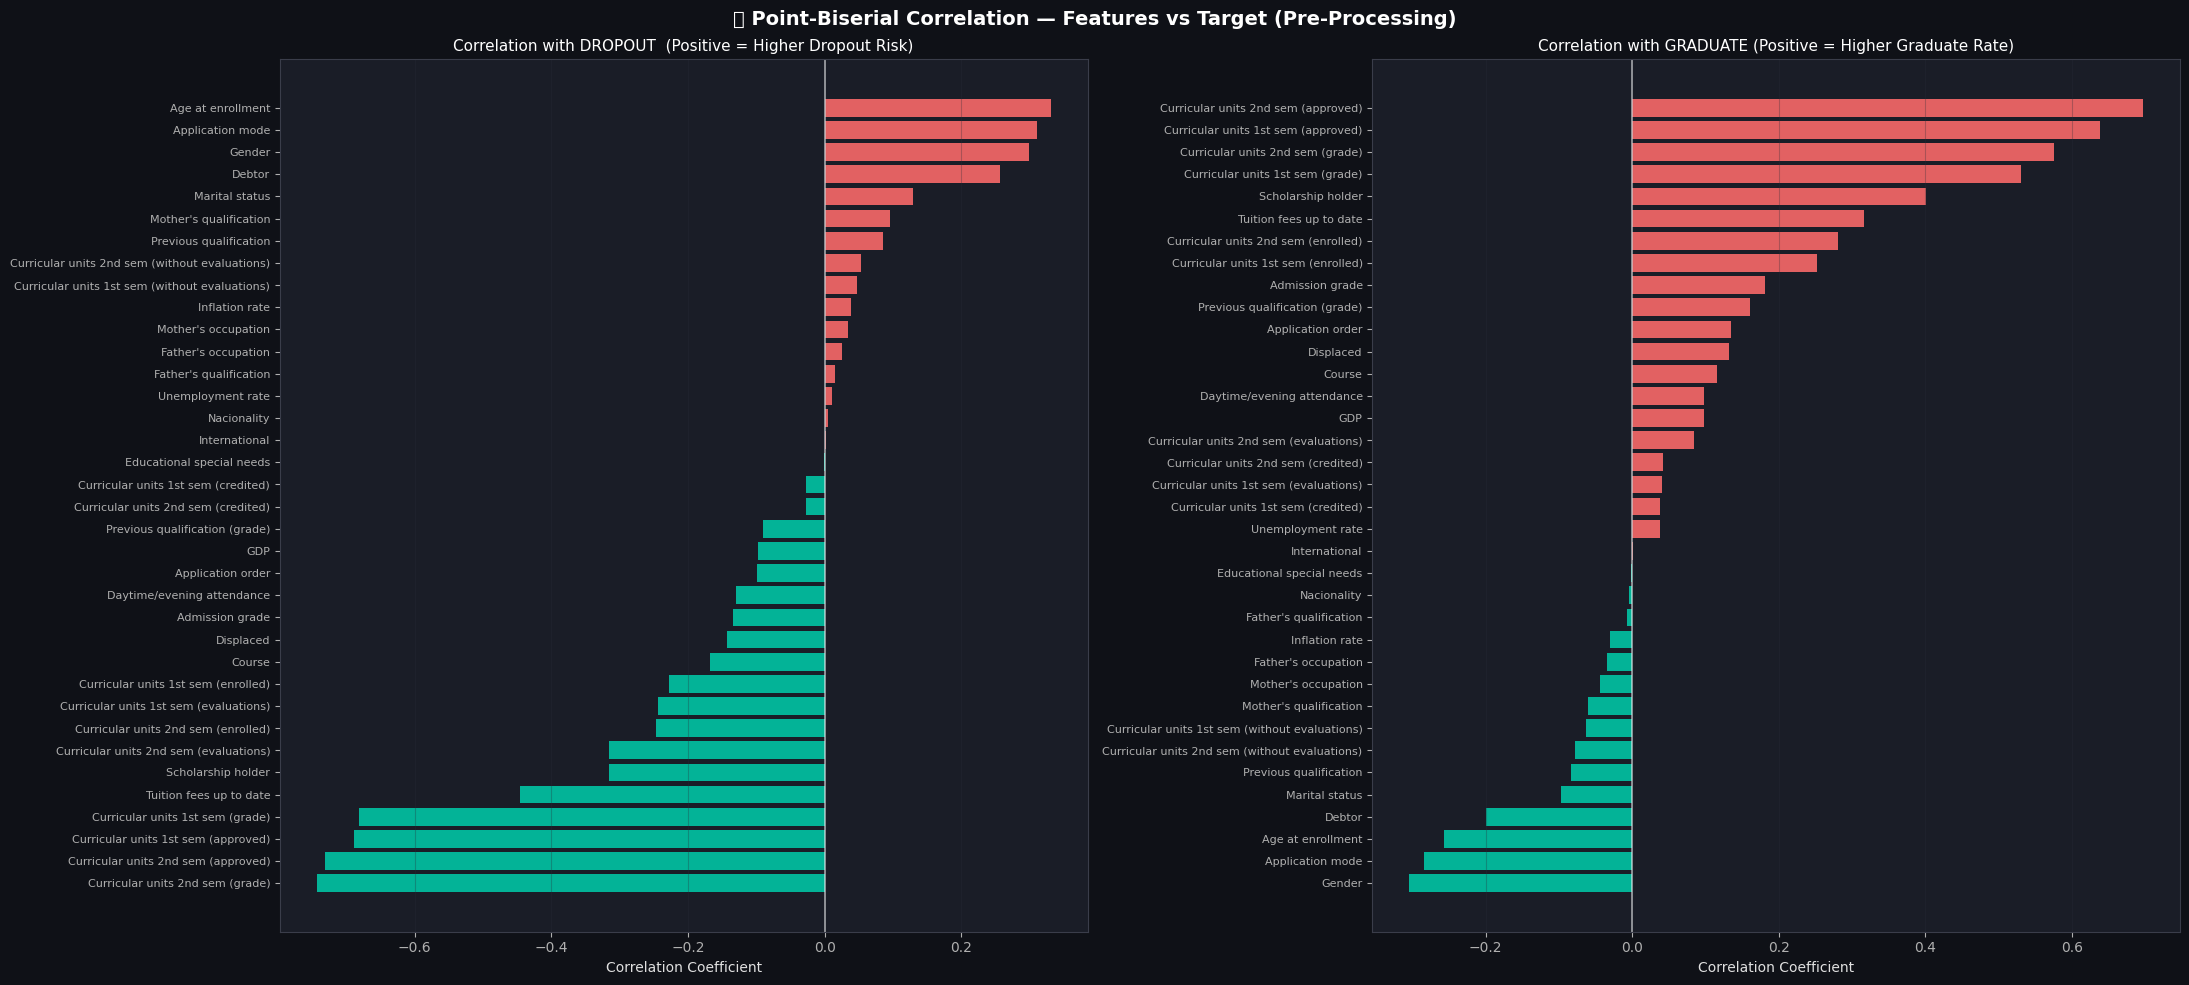

✅ Figure 7 saved: fig07_feature_correlations.png

🔍 TOP DROPOUT PREDICTORS:
   Age at enrollment                                 : r = +0.3309
   Application mode                                  : r = +0.3104
   Gender                                            : r = +0.2983
   Debtor                                            : r = +0.2561
   Marital status                                    : r = +0.1286


In [22]:
num_feats = [c for c in train.columns
             if c not in ['id', 'Target']]

is_dropout  = (train['Target'] == 'Dropout').astype(int)
is_graduate = (train['Target'] == 'Graduate').astype(int)

corr_d  = {c: stats.pointbiserialr(train[c], is_dropout)[0]  for c in num_feats}
corr_g  = {c: stats.pointbiserialr(train[c], is_graduate)[0] for c in num_feats}

df_corr = pd.DataFrame({
    'Feature':    list(corr_d.keys()),
    'vs_Dropout': list(corr_d.values()),
    'vs_Graduate':list(corr_g.values()),
})

fig, axes = plt.subplots(1, 2, figsize=(22, 10), facecolor=COLORS['bg'])
fig.suptitle('📊 Point-Biserial Correlation — Features vs Target (Pre-Processing)',
             fontsize=14, color='white', fontweight='bold')

for ax, col, title in [
    (axes[0], 'vs_Dropout',  'Correlation with DROPOUT  (Positive = Higher Dropout Risk)'),
    (axes[1], 'vs_Graduate', 'Correlation with GRADUATE (Positive = Higher Graduate Rate)'),
]:
    ax.set_facecolor(COLORS['panel'])
    sorted_df = df_corr.sort_values(col)
    colors_bar = [COLORS['Dropout'] if v > 0 else COLORS['Graduate']
                  for v in sorted_df[col]]
    ax.barh(sorted_df['Feature'], sorted_df[col],
            color=colors_bar, edgecolor='none', alpha=0.88)
    ax.axvline(0, color='white', linewidth=1.2, alpha=0.6)
    ax.set_xlabel('Correlation Coefficient', fontsize=10)
    ax.set_title(title, fontsize=11, color='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#3a3d4a')
    ax.xaxis.grid(True, alpha=0.3)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('fig07_feature_correlations.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Figure 7 saved: fig07_feature_correlations.png')

print('\n🔍 TOP DROPOUT PREDICTORS:')
top_d = df_corr.nlargest(5, 'vs_Dropout')
for _, row in top_d.iterrows():
    print(f'   {row["Feature"]:<50}: r = {row["vs_Dropout"]:+.4f}')

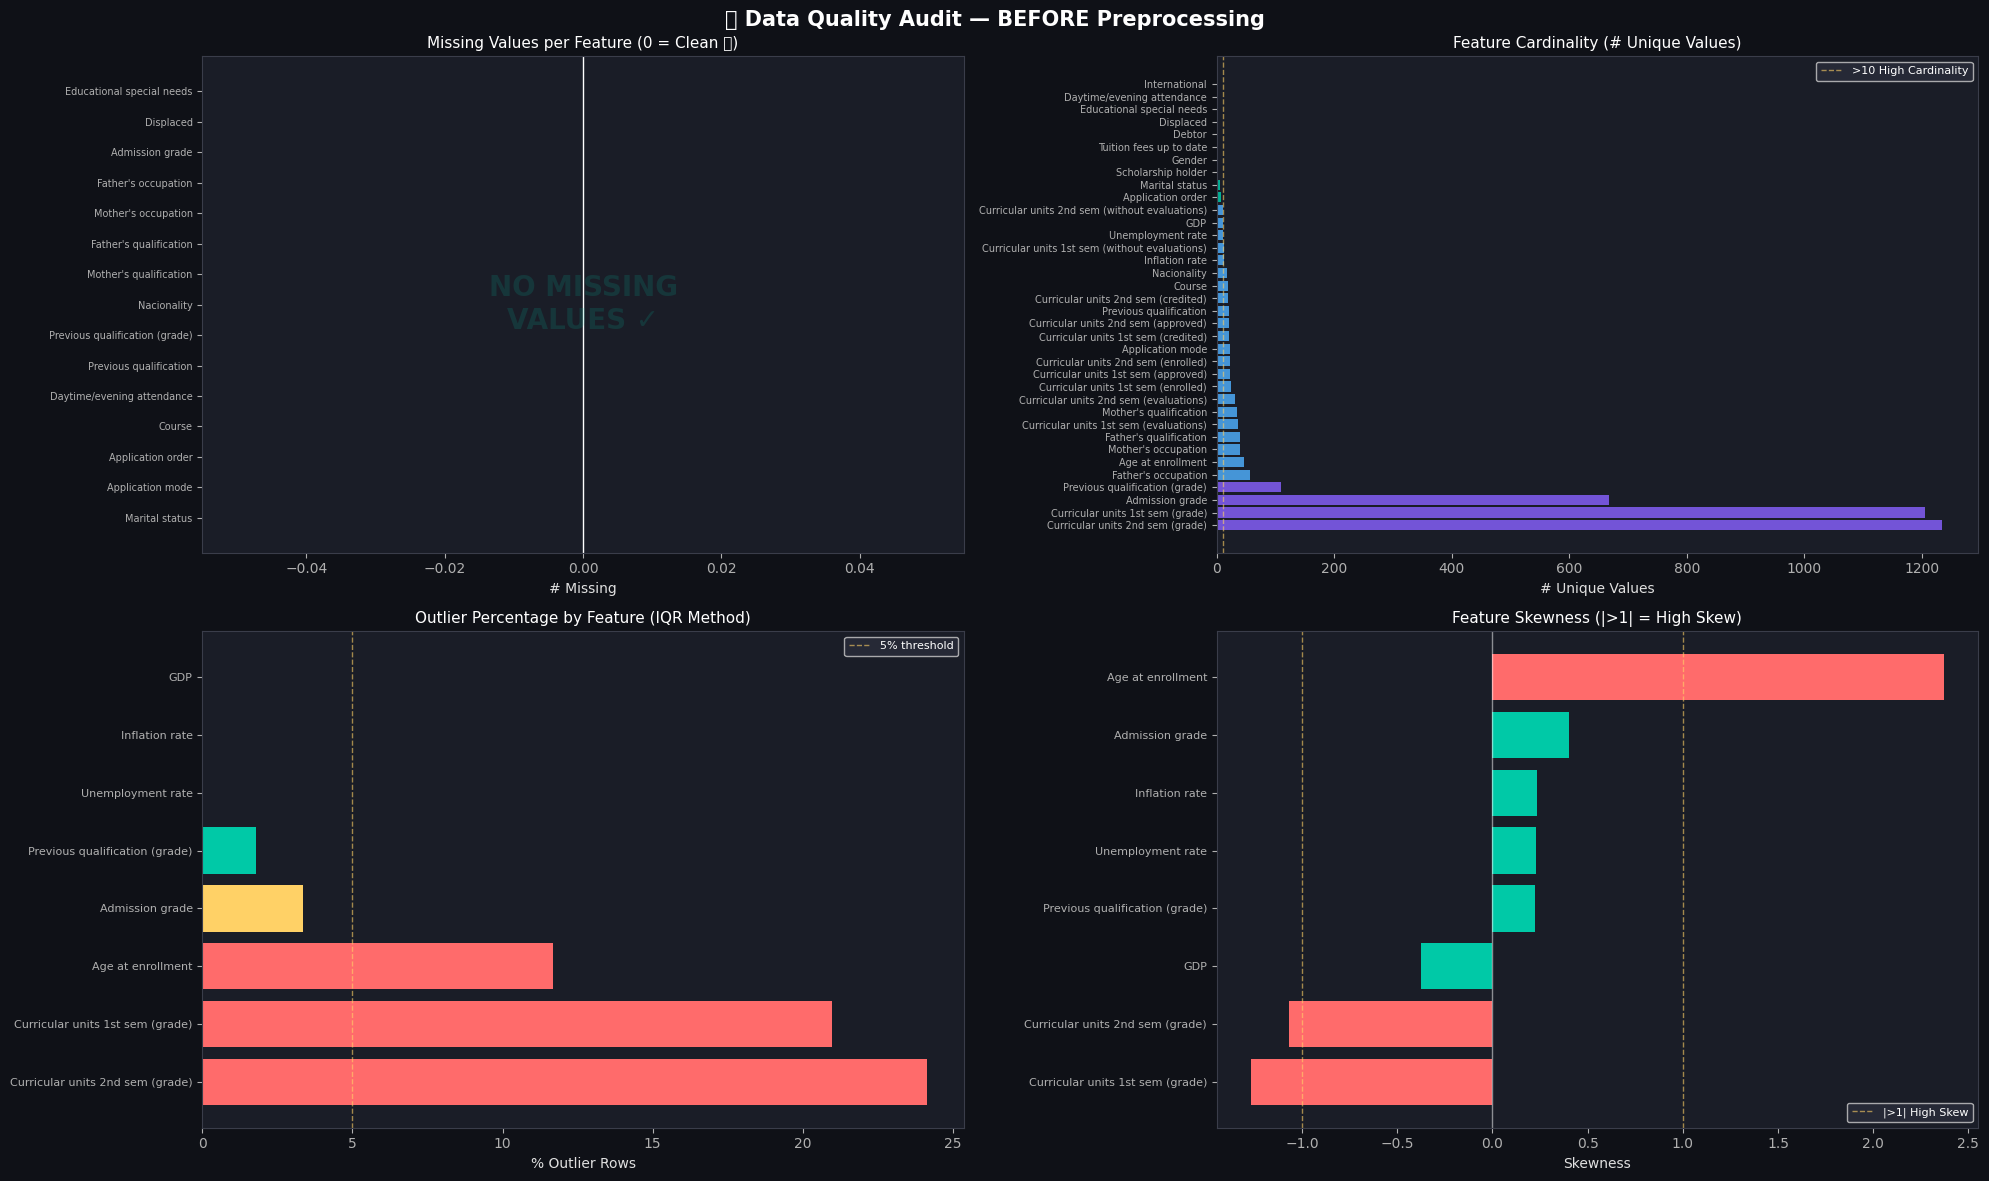

✅ Figure 8 saved: fig08_data_quality.png

✅ ALL PRE-PROCESSING EDA COMPLETE (8 figures)


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12), facecolor=COLORS['bg'])
fig.suptitle('🔍 Data Quality Audit — BEFORE Preprocessing',
             fontsize=15, color='white', fontweight='bold')

# — Missing values
ax = axes[0, 0]
ax.set_facecolor(COLORS['panel'])
miss = train.drop(columns=['id','Target']).isnull().sum()
miss_df = miss.sort_values(ascending=False).head(15)
colors_miss = [COLORS['Dropout'] if v > 0 else COLORS['Graduate'] for v in miss_df.values]
ax.barh(miss_df.index, miss_df.values, color=colors_miss, edgecolor='none')
ax.set_title('Missing Values per Feature (0 = Clean ✅)', fontsize=11)
ax.set_xlabel('# Missing')
ax.axvline(0, color='white', lw=1)
ax.text(0.5, 0.5, 'NO MISSING\nVALUES ✓', transform=ax.transAxes,
        ha='center', va='center', fontsize=20, color=COLORS['Graduate'],
        fontweight='bold', alpha=0.15)
for spine in ax.spines.values(): spine.set_edgecolor('#3a3d4a')
ax.tick_params(axis='y', labelsize=7)

# — Feature Cardinality
ax = axes[0, 1]
ax.set_facecolor(COLORS['panel'])
feats = train.drop(columns=['id','Target']).columns.tolist()
nuniq = [train[c].nunique() for c in feats]
card_df = pd.Series(nuniq, index=feats).sort_values(ascending=False)
color_card = [COLORS['accent'] if v > 100 else
              COLORS['blue']   if v > 10  else
              COLORS['Graduate'] for v in card_df.values]
ax.barh(card_df.index, card_df.values, color=color_card, edgecolor='none', alpha=0.85)
ax.set_title('Feature Cardinality (# Unique Values)', fontsize=11)
ax.set_xlabel('# Unique Values')
ax.axvline(10, color='#ffd166', lw=1, linestyle='--', alpha=0.6, label='>10 High Cardinality')
ax.legend(fontsize=8, facecolor='#2a2d3a', labelcolor='white')
for spine in ax.spines.values(): spine.set_edgecolor('#3a3d4a')
ax.tick_params(axis='y', labelsize=7)

# — Outlier Percentage
ax = axes[1, 0]
ax.set_facecolor(COLORS['panel'])
outlier_pct = {}
for c in cont_feats:
    Q1, Q3 = train[c].quantile(0.25), train[c].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((train[c] < Q1-1.5*IQR) | (train[c] > Q3+1.5*IQR)).sum()
    outlier_pct[c] = n_out / len(train) * 100
outlier_s = pd.Series(outlier_pct).sort_values(ascending=False)
colors_out = [COLORS['Dropout'] if v > 5 else
              COLORS['Enrolled'] if v > 2 else
              COLORS['Graduate'] for v in outlier_s.values]
ax.barh(outlier_s.index, outlier_s.values, color=colors_out, edgecolor='none')
ax.set_title('Outlier Percentage by Feature (IQR Method)', fontsize=11)
ax.set_xlabel('% Outlier Rows')
ax.axvline(5, color='#ffd166', lw=1, linestyle='--', alpha=0.6, label='5% threshold')
ax.legend(fontsize=8, facecolor='#2a2d3a', labelcolor='white')
for spine in ax.spines.values(): spine.set_edgecolor('#3a3d4a')
ax.tick_params(axis='y', labelsize=8)

# — Skewness
ax = axes[1, 1]
ax.set_facecolor(COLORS['panel'])
skew_vals = train[cont_feats].skew().sort_values()
colors_sk = [COLORS['Dropout'] if abs(v) > 1 else
             COLORS['Enrolled'] if abs(v) > 0.5 else
             COLORS['Graduate'] for v in skew_vals.values]
ax.barh(skew_vals.index, skew_vals.values, color=colors_sk, edgecolor='none')
ax.axvline(0,  color='white',   lw=1, alpha=0.5)
ax.axvline(1,  color='#ffd166', lw=1, linestyle='--', alpha=0.6, label='|>1| High Skew')
ax.axvline(-1, color='#ffd166', lw=1, linestyle='--', alpha=0.6)
ax.set_title('Feature Skewness (|>1| = High Skew)', fontsize=11)
ax.set_xlabel('Skewness')
ax.legend(fontsize=8, facecolor='#2a2d3a', labelcolor='white')
for spine in ax.spines.values(): spine.set_edgecolor('#3a3d4a')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('fig08_data_quality.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Figure 8 saved: fig08_data_quality.png')
print('\n✅ ALL PRE-PROCESSING EDA COMPLETE (8 figures)')

# 5. Feature Engineering


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Feature Engineering
# ─────────────────────────────────────────────────────────────────────────────
def engineer_features(df):

    d = df.copy()

    # ── A. ACADEMIC PERFORMANCE AGGREGATES ───────────────────────────────────
    # Total approved units across both semesters
    d['total_approved'] = (d['Curricular units 1st sem (approved)'] +
                           d['Curricular units 2nd sem (approved)'])

    # Total enrolled units
    d['total_enrolled'] = (d['Curricular units 1st sem (enrolled)'] +
                           d['Curricular units 2nd sem (enrolled)'])

    # Total evaluations
    d['total_evaluations'] = (d['Curricular units 1st sem (evaluations)'] +
                              d['Curricular units 2nd sem (evaluations)'])

    # Average grade both semesters
    d['avg_grade'] = (d['Curricular units 1st sem (grade)'] +
                      d['Curricular units 2nd sem (grade)']) / 2

    # Grade improvement from Sem1 to Sem2 (progression indicator)
    d['grade_improvement'] = (d['Curricular units 2nd sem (grade)'] -
                               d['Curricular units 1st sem (grade)'])

    # Approval improvement from Sem1 to Sem2
    d['approval_improvement'] = (d['Curricular units 2nd sem (approved)'] -
                                  d['Curricular units 1st sem (approved)'])

    # Max grade across both semesters
    d['max_grade'] = d[['Curricular units 1st sem (grade)',
                         'Curricular units 2nd sem (grade)']].max(axis=1)

    # Min grade across both semesters
    d['min_grade'] = d[['Curricular units 1st sem (grade)',
                         'Curricular units 2nd sem (grade)']].min(axis=1)

    # Grade std (consistency indicator)
    d['grade_std'] = d[['Curricular units 1st sem (grade)',
                         'Curricular units 2nd sem (grade)']].std(axis=1).fillna(0)

    # ── B. EFFICIENCY RATIOS ─────────────────────────────────────────────────
    # Approval rate Sem1: how many enrolled units were approved
    d['approval_rate_sem1'] = np.where(
        d['Curricular units 1st sem (enrolled)'] > 0,
        d['Curricular units 1st sem (approved)'] /
        d['Curricular units 1st sem (enrolled)'],
        0
    )

    # Approval rate Sem2
    d['approval_rate_sem2'] = np.where(
        d['Curricular units 2nd sem (enrolled)'] > 0,
        d['Curricular units 2nd sem (approved)'] /
        d['Curricular units 2nd sem (enrolled)'],
        0
    )

    # Overall approval rate
    d['overall_approval_rate'] = np.where(
        d['total_enrolled'] > 0,
        d['total_approved'] / d['total_enrolled'],
        0
    )

    # Evaluation-to-approval ratio (efficiency)
    d['eval_to_approval'] = np.where(
        d['total_approved'] > 0,
        d['total_evaluations'] / d['total_approved'],
        0
    )

    # ── C. FINANCIAL RISK SCORE ──────────────────────────────────────────────
    # Higher = more financial stress
    d['financial_risk'] = (
        (1 - d['Tuition fees up to date']) * 3 +   # Heaviest weight
        d['Debtor'] * 2 +
        (1 - d['Scholarship holder']) * 1
    )

    # ── D. COMBINED ACADEMIC RISK SCORE ──────────────────────────────────────
    # Higher = more at risk
    d['academic_risk_score'] = (
        (1 - d['overall_approval_rate']) * 5 +
        d['financial_risk'] * 2 +
        np.where(d['avg_grade'] < 10, 1, 0) * 3
    )

    # ── E. STUDENT PROFILE FLAGS ─────────────────────────────────────────────
    # Perfect attender: enrolled everything, approved everything
    d['is_perfect_approver'] = (d['overall_approval_rate'] == 1.0).astype(int)

    # Zero approved (failed all enrolled units)
    d['zero_approved'] = (d['total_approved'] == 0).astype(int)

    # Zero enrolled (didn't enroll in anything — edge case)
    d['zero_enrolled'] = (d['total_enrolled'] == 0).astype(int)

    # High achiever flag (avg_grade > 14)
    d['high_achiever'] = (d['avg_grade'] > 14).astype(int)

    # ── F. AGE-RELATED FEATURES ──────────────────────────────────────────────
    # Age group buckets
    d['age_group'] = pd.cut(
        d['Age at enrollment'],
        bins=[16, 19, 23, 30, 100],
        labels=[0, 1, 2, 3]
    ).astype(int)

    # Older student flag (>25)
    d['is_older_student'] = (d['Age at enrollment'] > 25).astype(int)

    # ── G. MACROECONOMIC INTERACTION ─────────────────────────────────────────
    # Economic stress: high unemployment + low GDP
    d['economic_stress'] = d['Unemployment rate'] - d['GDP']

    # Unemployment × Debtor interaction
    d['unemployment_x_debtor'] = d['Unemployment rate'] * d['Debtor']

    # ── H. SEM1 × SEM2 PRODUCT (interaction) ─────────────────────────────────
    d['grade_product'] = (d['Curricular units 1st sem (grade)'] *
                          d['Curricular units 2nd sem (grade)'])

    d['approved_product'] = (d['Curricular units 1st sem (approved)'] *
                              d['Curricular units 2nd sem (approved)'])

    return d




In [25]:
# Apply to both train and test
train_fe = engineer_features(train)
test_fe  = engineer_features(test)

new_features = [
    'total_approved', 'total_enrolled', 'total_evaluations', 'avg_grade',
    'grade_improvement', 'approval_improvement', 'max_grade', 'min_grade',
    'grade_std', 'approval_rate_sem1', 'approval_rate_sem2',
    'overall_approval_rate', 'eval_to_approval', 'financial_risk',
    'academic_risk_score', 'is_perfect_approver', 'zero_approved',
    'zero_enrolled', 'high_achiever', 'age_group', 'is_older_student',
    'economic_stress', 'unemployment_x_debtor', 'grade_product', 'approved_product'
]

print(f'✅ Feature Engineering Complete!')
print(f'   Original features : {train.shape[1] - 2}')  # -id -Target
print(f'   New features added: {len(new_features)}')
print(f'   Total features    : {train_fe.shape[1] - 2}')
print(f'\n   New features preview:')
display(train_fe[new_features].describe())

✅ Feature Engineering Complete!
   Original features : 36
   New features added: 25
   Total features    : 61

   New features preview:


,total_approved,total_enrolled,total_evaluations,avg_grade,grade_improvement,approval_improvement,max_grade,min_grade,grade_std,approval_rate_sem1,approval_rate_sem2,overall_approval_rate,eval_to_approval,financial_risk,academic_risk_score,is_perfect_approver,zero_approved,zero_enrolled,high_achiever,age_group,is_older_student,economic_stress,unemployment_x_debtor,grade_product,approved_product
count,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000,76518.0000
mean,8.1857,11.8249,14.5868,9.8110,-0.3698,-0.1713,10.3399,9.2821,0.7480,0.6683,0.6337,0.6509,1.8458,1.2144,4.9168,0.3144,0.2037,0.0349,0.1026,0.8253,0.1920,11.6013,0.8462,122.1870,23.6213
std,5.3543,3.2627,6.6269,5.2536,2.5569,1.0771,5.3415,5.4266,1.6667,0.3930,0.4055,0.3898,2.7221,1.3909,5.0431,0.4643,0.4027,0.1835,0.3035,1.0425,0.3939,3.9599,3.1358,74.5763,22.8235
min,0.0000,0.0000,0.0000,0.0000,-18.0000,-14.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-3.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5.3900,0.0000,0.0000,0.0000
25%,3.0000,10.0000,12.0000,10.0000,-0.5000,0.0000,11.0000,10.0000,0.0000,0.4000,0.1667,0.3000,1.0000,1.0000,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,9.0600,0.0000,100.0000,1.0000
50%,10.0000,12.0000,15.0000,12.1250,0.0000,0.0000,12.6000,11.7500,0.3026,0.8333,0.8333,0.8333,1.2000,1.0000,2.7143,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,10.6100,0.0000,146.9333,25.0000
75%,12.0000,12.0000,18.0000,13.1667,0.3333,0.0000,13.5833,12.8571,0.7071,1.0000,1.0000,1.0000,1.9000,1.0000,9.2500,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,14.4000,0.0000,173.2500,36.0000
max,43.0000,46.0000,66.0000,18.2837,16.5000,16.0000,18.8750,17.6923,12.7279,2.0000,5.0000,2.0000,37.0000,6.0000,20.0000,1.0000,1.0000,1.0000,1.0000,3.0000,1.0000,19.5600,16.2000,333.9423,442.0000


# 6. EDA — Post Feature Engineering

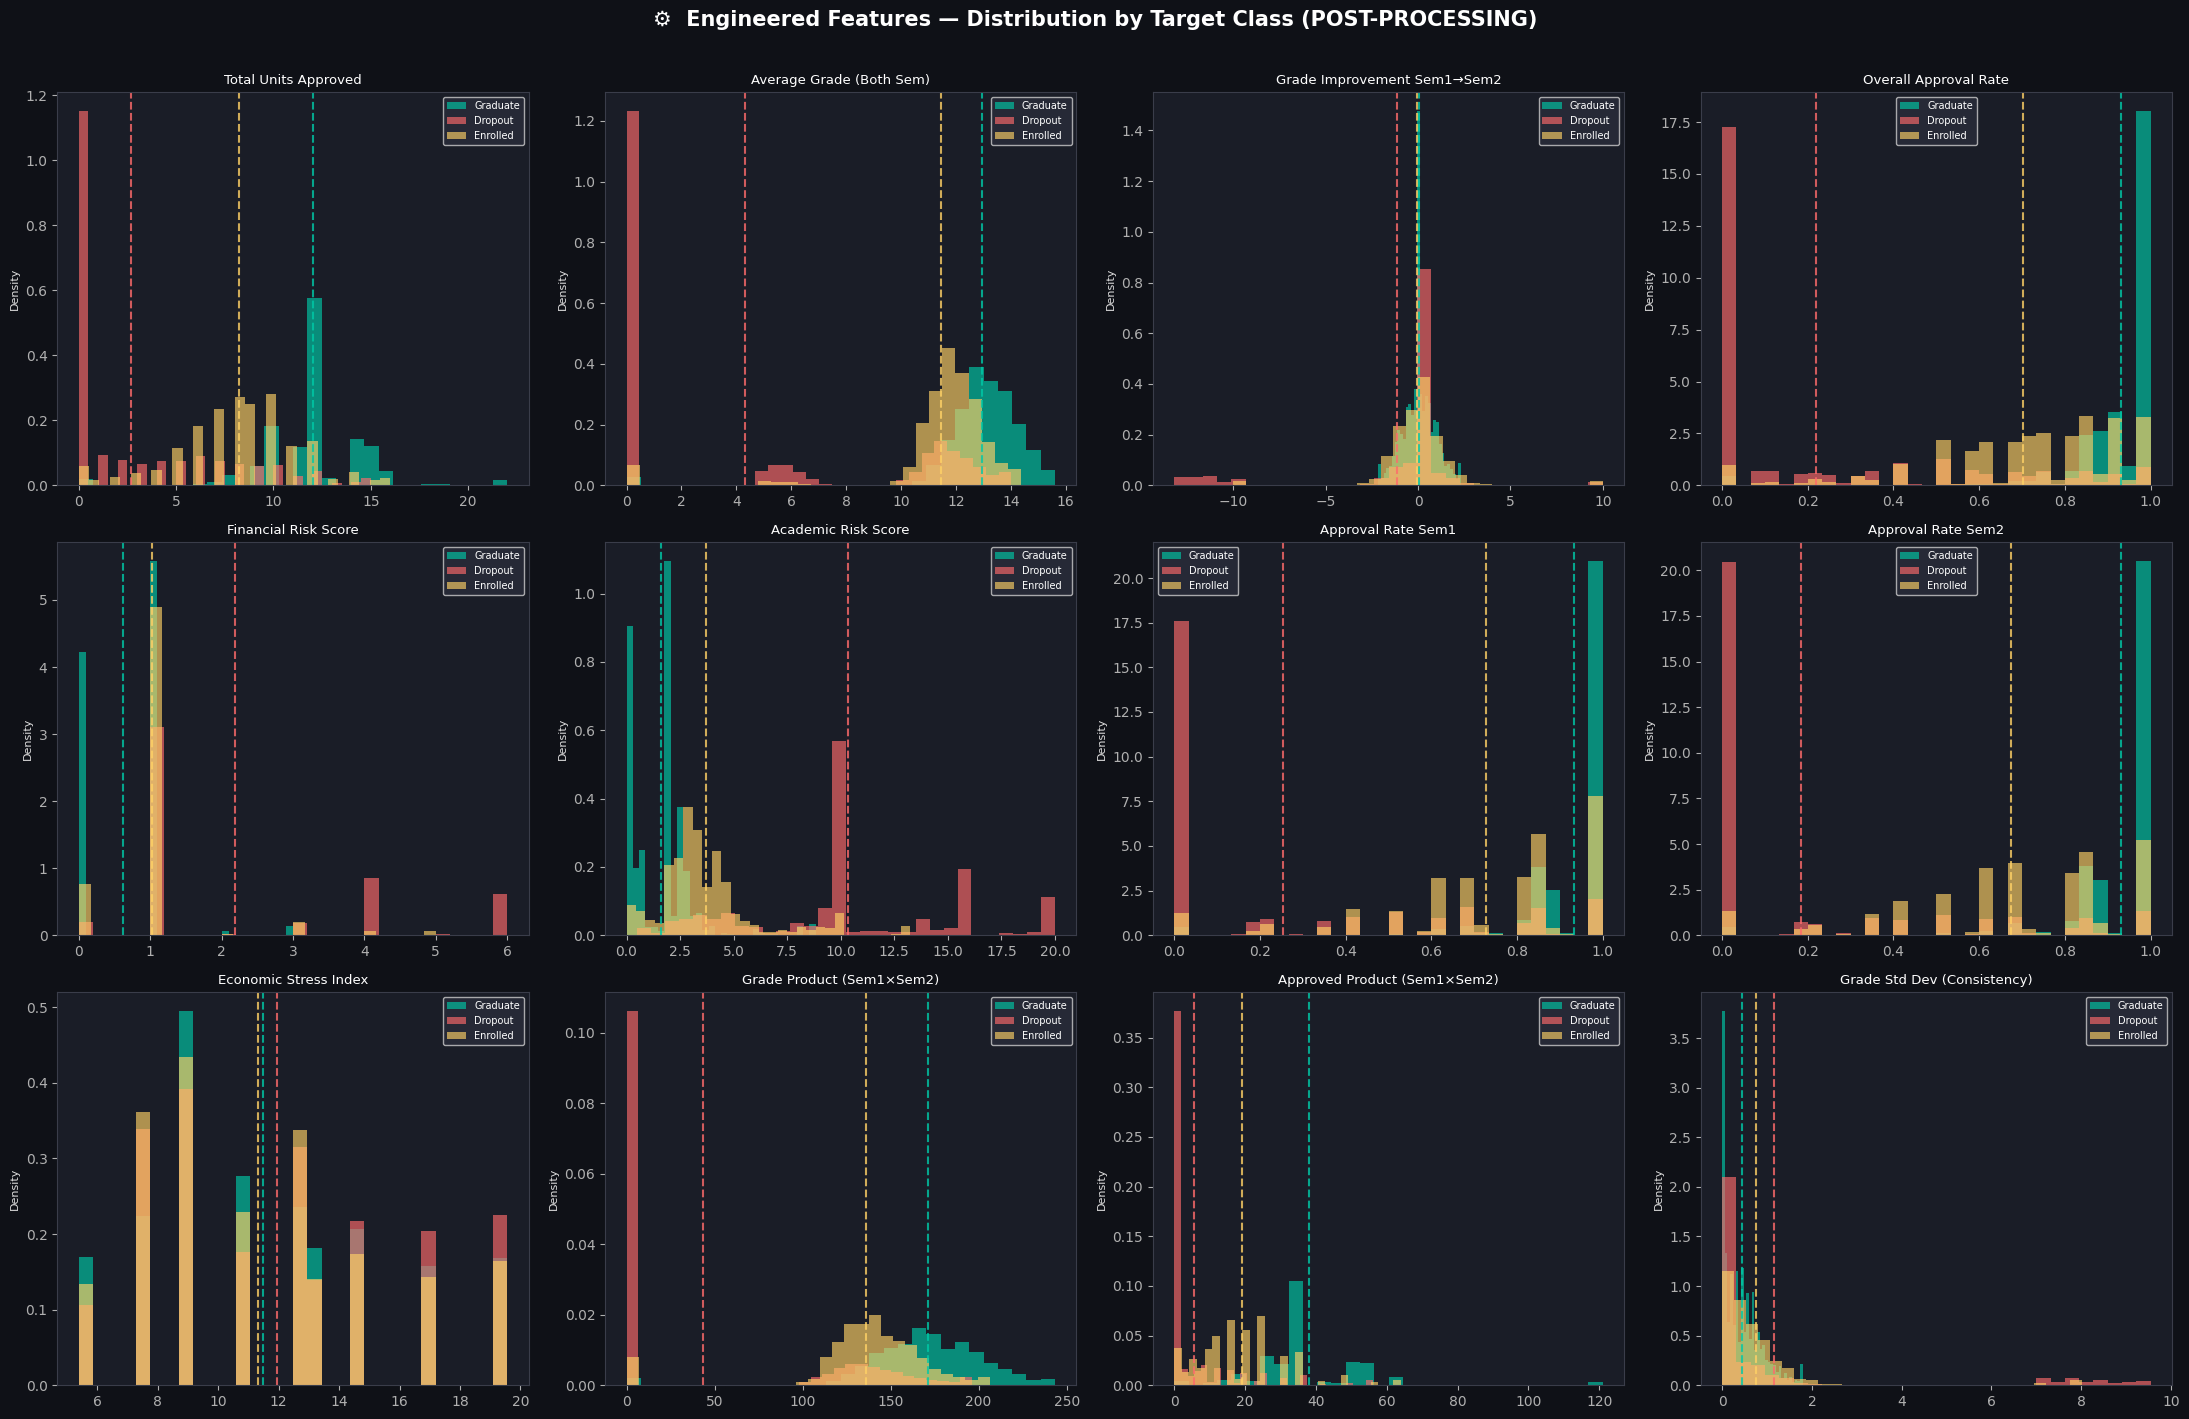

✅ Figure 9 saved: fig09_engineered_features.png

📊 FEATURE SEPARATION (Mean by Class — Engineered Features):


,avg_grade,overall_approval_rate,financial_risk,academic_risk_score,total_approved
Target,,,,,
Dropout,4.3250,0.2180,2.1840,10.3570,2.6660
Enrolled,11.4500,0.7010,1.0270,3.7130,8.2060
Graduate,12.9610,0.9320,0.6160,1.6190,12.0260


In [26]:
fig, axes = plt.subplots(3, 4, figsize=(22, 14), facecolor=COLORS['bg'])
fig.suptitle('⚙️  Engineered Features — Distribution by Target Class (POST-PROCESSING)',
             fontsize=15, color='white', fontweight='bold', y=1.01)

plot_features = [
    ('total_approved',       'Total Units Approved'),
    ('avg_grade',            'Average Grade (Both Sem)'),
    ('grade_improvement',    'Grade Improvement Sem1→Sem2'),
    ('overall_approval_rate','Overall Approval Rate'),
    ('financial_risk',       'Financial Risk Score'),
    ('academic_risk_score',  'Academic Risk Score'),
    ('approval_rate_sem1',   'Approval Rate Sem1'),
    ('approval_rate_sem2',   'Approval Rate Sem2'),
    ('economic_stress',      'Economic Stress Index'),
    ('grade_product',        'Grade Product (Sem1×Sem2)'),
    ('approved_product',     'Approved Product (Sem1×Sem2)'),
    ('grade_std',            'Grade Std Dev (Consistency)'),
]

for ax, (col, title) in zip(axes.flatten(), plot_features):
    ax.set_facecolor(COLORS['panel'])
    for target, color in zip(TARGET_ORDER, PALETTE):
        subset = train_fe[train_fe['Target'] == target][col]
        ax.hist(subset.clip(
            subset.quantile(0.01), subset.quantile(0.99)
        ), bins=30, alpha=0.65, color=color, label=target, density=True)
        ax.axvline(subset.mean(), color=color, linestyle='--',
                   linewidth=1.5, alpha=0.8)
    ax.set_title(title, fontsize=9.5, color='white')
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7, facecolor='#2a2d3a', labelcolor='white', framealpha=0.8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#3a3d4a')

plt.tight_layout()
plt.savefig('fig09_engineered_features.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Figure 9 saved: fig09_engineered_features.png')

# Print separation statistics for key features
print('\n📊 FEATURE SEPARATION (Mean by Class — Engineered Features):')
key_feats = ['avg_grade', 'overall_approval_rate', 'financial_risk',
             'academic_risk_score', 'total_approved']
sep_df = train_fe.groupby('Target')[key_feats].mean().round(3)
display(sep_df)

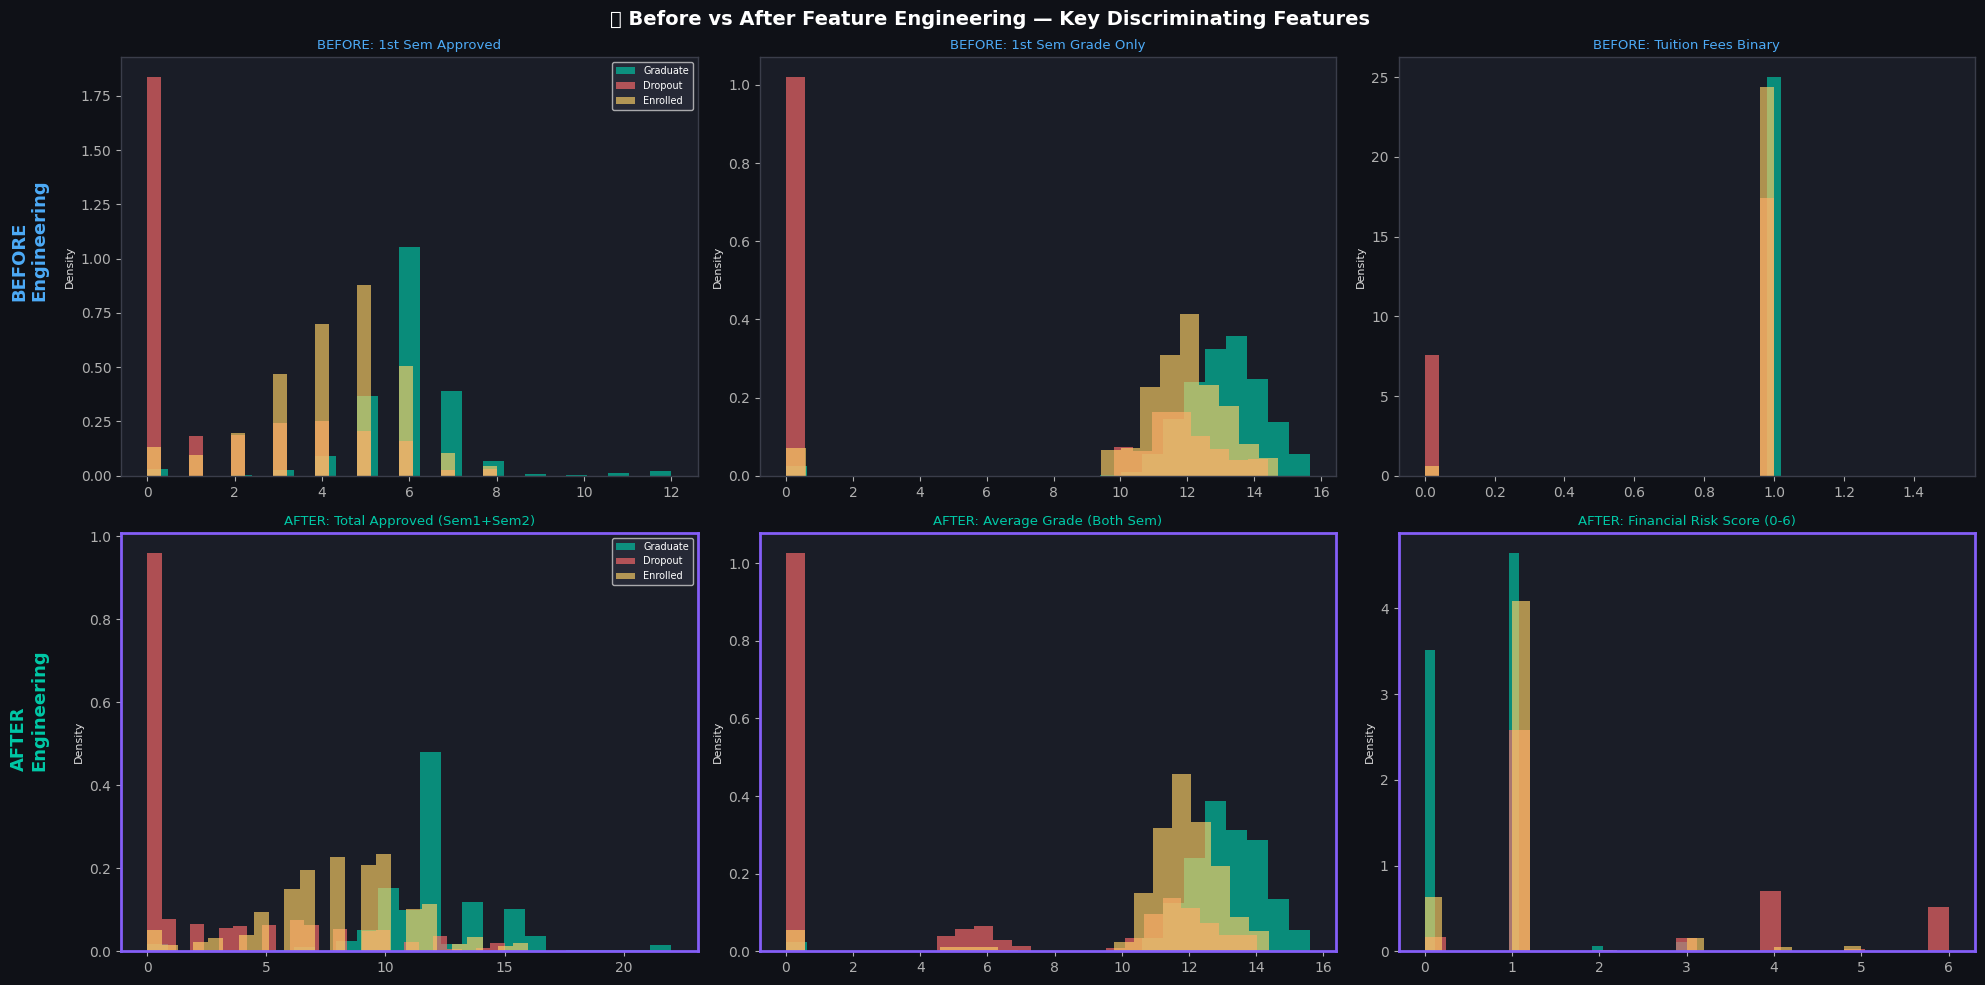

✅ Figure 10 saved: fig10_before_after_engineering.png


In [27]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10), facecolor=COLORS['bg'])
fig.suptitle('🔄 Before vs After Feature Engineering — Key Discriminating Features',
             fontsize=14, color='white', fontweight='bold')

comparisons = [
    # (Before-col, After-col, title_before, title_after)
    ('Curricular units 1st sem (approved)',
     'total_approved',
     'BEFORE: 1st Sem Approved',
     'AFTER: Total Approved (Sem1+Sem2)'),
    ('Curricular units 1st sem (grade)',
     'avg_grade',
     'BEFORE: 1st Sem Grade Only',
     'AFTER: Average Grade (Both Sem)'),
    ('Tuition fees up to date',
     'financial_risk',
     'BEFORE: Tuition Fees Binary',
     'AFTER: Financial Risk Score (0-6)'),
]

for i, (b_col, a_col, b_title, a_title) in enumerate(comparisons):
    for j, (col, title) in enumerate([(b_col, b_title), (a_col, a_title)]):
        ax = axes[j, i]
        ax.set_facecolor(COLORS['panel'])
        for target, color in zip(TARGET_ORDER, PALETTE):
            vals = train_fe[train_fe['Target'] == target][col]
            ax.hist(vals.clip(vals.quantile(0.01), vals.quantile(0.99)),
                    bins=25, alpha=0.65, color=color, label=target, density=True)
        ax.set_title(title, fontsize=9.5,
                     color='#4dabf7' if j == 0 else '#00c9a7')
        ax.set_ylabel('Density', fontsize=8)
        if i == 0: ax.legend(fontsize=7, facecolor='#2a2d3a', labelcolor='white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#845ef7' if j == 1 else '#3a3d4a')
            spine.set_linewidth(2 if j == 1 else 1)

# Add labels
fig.text(0.01, 0.75, 'BEFORE\nEngineering', rotation=90, va='center',
         fontsize=13, color='#4dabf7', fontweight='bold')
fig.text(0.01, 0.28, 'AFTER\nEngineering', rotation=90, va='center',
         fontsize=13, color='#00c9a7', fontweight='bold')

plt.tight_layout(rect=[0.03, 0, 1, 1])
plt.savefig('fig10_before_after_engineering.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Figure 10 saved: fig10_before_after_engineering.png')

# 7. Preprocessing Pipeline

In [28]:
# Features to drop (id is not predictive)
DROP_COLS = ['id']

# Encode target
le = LabelEncoder()
y = le.fit_transform(train_fe['Target'])

# Store class names for later
class_names = le.classes_.tolist()
print(f'Target encoding: {dict(zip(range(len(class_names)), class_names))}')

# Prepare feature matrix
X = train_fe.drop(columns=DROP_COLS + ['Target'])
X_test = test_fe.drop(columns=DROP_COLS)

# Align columns (just in case)
X_test = X_test[X.columns]

print(f'\n✅ Preprocessing complete:')
print(f'   X shape      : {X.shape}')
print(f'   X_test shape : {X_test.shape}')
print(f'   y classes    : {np.bincount(y)} → {dict(zip(class_names, np.bincount(y)))}')
print(f'\n   Feature list ({len(X.columns)} features):')
for i, c in enumerate(X.columns.tolist()):
    print(f'   [{i+1:02d}] {c}')

Target encoding: {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}

✅ Preprocessing complete:
   X shape      : (76518, 61)
   X_test shape : (51012, 61)
   y classes    : [25296 14940 36282] → {'Dropout': np.int64(25296), 'Enrolled': np.int64(14940), 'Graduate': np.int64(36282)}

   Feature list (61 features):
   [01] Marital status
   [02] Application mode
   [03] Application order
   [04] Course
   [05] Daytime/evening attendance
   [06] Previous qualification
   [07] Previous qualification (grade)
   [08] Nacionality
   [09] Mother's qualification
   [10] Father's qualification
   [11] Mother's occupation
   [12] Father's occupation
   [13] Admission grade
   [14] Displaced
   [15] Educational special needs
   [16] Debtor
   [17] Tuition fees up to date
   [18] Gender
   [19] Scholarship holder
   [20] Age at enrollment
   [21] International
   [22] Curricular units 1st sem (credited)
   [23] Curricular units 1st sem (enrolled)
   [24] Curricular units 1st sem (evaluations)
   [25] Curr

# 8️. Baseline Models — Cross-Validation

In [29]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

baseline_models = {
    
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=12, random_state=SEED, n_jobs=MAX_LOCAL_JOBS),
        
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        tree_method='hist',      # Algoritma histogram yang sangat cepat
        device='cuda',           # 🚀 MENGAKTIFKAN NVIDIA CUDA RTX 4050
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=SEED),
        
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, n_jobs=MAX_LOCAL_JOBS, verbose=-1), # Tetap di CPU Cores yang kencang
        
    'CatBoost': CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.1,
        task_type='GPU',         # 🚀 MENGAKTIFKAN GPU UNTUK CATBOOST
        random_state=SEED, verbose=0),
}

print('🔄 Running 5-Fold Stratified Cross-Validation...')
print('-' * 55)
baseline_results = {}

for name, model in baseline_models.items():
    if name in ['XGBoost', 'CatBoost']:
        scores = cross_val_score(model, X, y, cv=CV, scoring='accuracy', n_jobs=1)
    else:
        scores = cross_val_score(model, X, y, cv=CV, scoring='accuracy', n_jobs=MAX_LOCAL_JOBS)
        
    baseline_results[name] = scores
    print(f'  {name:<15}: {scores.mean():.5f} ± {scores.std():.5f}')

print('-' * 55)
best_baseline = max(baseline_results, key=lambda k: baseline_results[k].mean())
print(f'\n  🏆 Best Baseline: {best_baseline} '
      f'({baseline_results[best_baseline].mean():.5f})')
print(f'  🎯 Target Score : 0.84200')

🔄 Running 5-Fold Stratified Cross-Validation...
-------------------------------------------------------
  RandomForest   : 0.82475 ± 0.00215
  XGBoost        : 0.83160 ± 0.00172
  LightGBM       : 0.83116 ± 0.00129
  CatBoost       : 0.82970 ± 0.00196
-------------------------------------------------------

  🏆 Best Baseline: XGBoost (0.83160)
  🎯 Target Score : 0.84200


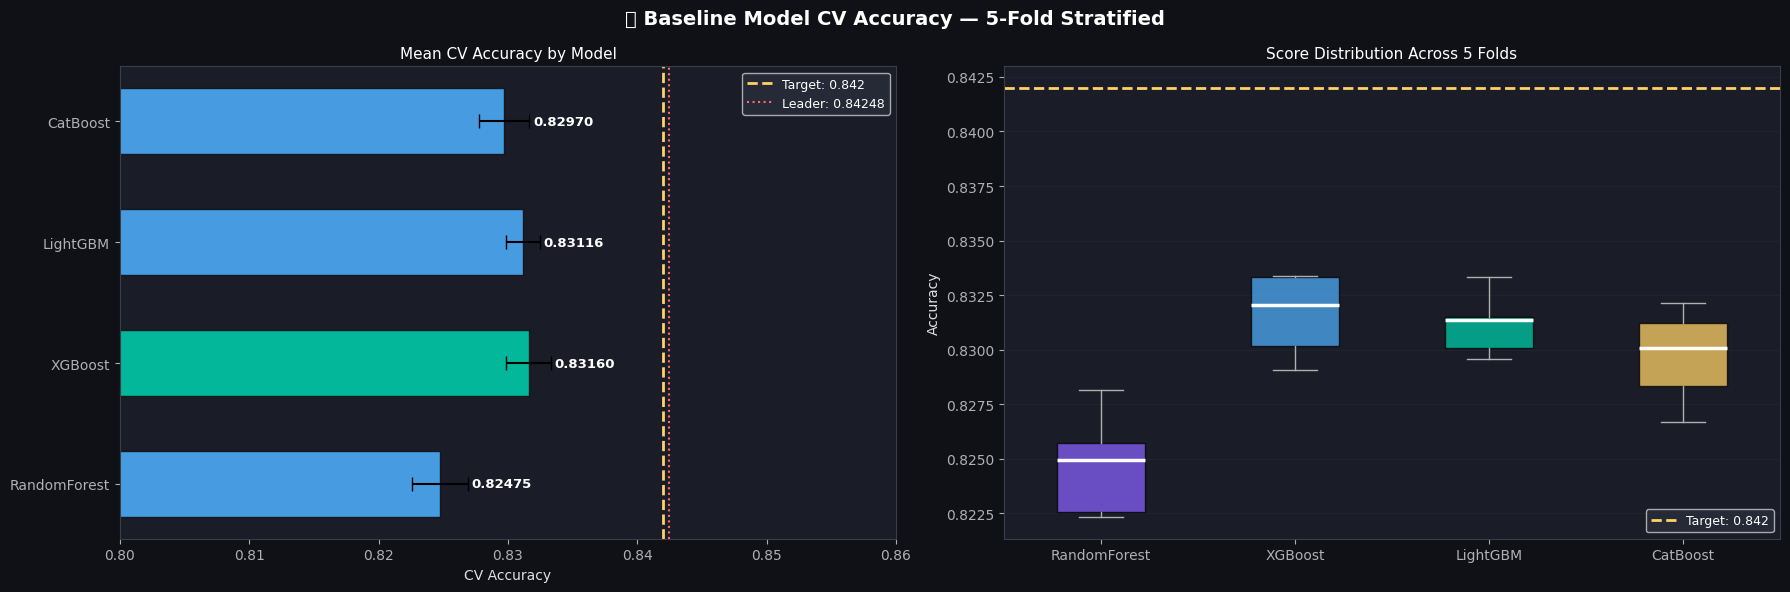

✅ Figure 11 saved: fig11_baseline_results.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=COLORS['bg'])
fig.suptitle('📊 Baseline Model CV Accuracy — 5-Fold Stratified',
             fontsize=14, color='white', fontweight='bold')

model_names = list(baseline_results.keys())
means = [baseline_results[m].mean() for m in model_names]
stds  = [baseline_results[m].std()  for m in model_names]
bar_colors = ['#00c9a7' if v == max(means) else '#4dabf7' for v in means]

# Bar chart
ax = axes[0]
ax.set_facecolor(COLORS['panel'])
bars = ax.barh(model_names, means, xerr=stds, color=bar_colors,
               capsize=5, edgecolor=COLORS['bg'], height=0.55, alpha=0.9)
ax.axvline(0.842, color='#ffd166', lw=2, linestyle='--', label='Target: 0.842')
ax.axvline(0.84248, color='#ff6b6b', lw=1.5, linestyle=':', label='Leader: 0.84248')
for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
    ax.text(mean + std + 0.0003, bar.get_y() + bar.get_height()/2,
            f'{mean:.5f}', va='center', ha='left', fontsize=9.5,
            color='white', fontweight='bold')
ax.set_xlabel('CV Accuracy', fontsize=10)
ax.set_title('Mean CV Accuracy by Model', fontsize=11)
ax.legend(fontsize=9, facecolor='#2a2d3a', labelcolor='white')
ax.set_xlim(0.80, 0.86)
for spine in ax.spines.values(): spine.set_edgecolor('#3a3d4a')

# Box plot of fold scores
ax = axes[1]
ax.set_facecolor(COLORS['panel'])
fold_data = [baseline_results[m] for m in model_names]
bp = ax.boxplot(
    fold_data, labels=model_names, patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(color='#b0b0b0'),
    capprops=dict(color='#b0b0b0'),
)
for patch, color in zip(bp['boxes'], ['#845ef7','#4dabf7','#00c9a7','#ffd166']):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.axhline(0.842, color='#ffd166', lw=2, linestyle='--', label='Target: 0.842')
ax.set_title('Score Distribution Across 5 Folds', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=10)
ax.legend(fontsize=9, facecolor='#2a2d3a', labelcolor='white')
for spine in ax.spines.values(): spine.set_edgecolor('#3a3d4a')
ax.yaxis.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig11_baseline_results.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Figure 11 saved: fig11_baseline_results.png')

## 9. Hyperparameter Tuning with Optuna

In [33]:
def objective_xgb(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 300, 1200),
        'max_depth':          trial.suggest_int('max_depth', 4, 10),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':          trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel':  trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_child_weight':   trial.suggest_int('min_child_weight', 1, 10),
        'gamma':              trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'tree_method':        'hist',
        'device':             'cuda', # 🚀 Optuna mengevaluasi tiap parameter langsung di RTX 4050
        'use_label_encoder':  False,
        'eval_metric':        'mlogloss',
        'random_state':       SEED,
    }
    
    model = xgb.XGBClassifier(**params)
    # n_jobs=1 karena komputasi paralel dieksekusi langsung secara masif di dalam GPU CUDA
    scores = cross_val_score(model, X, y, cv=CV, scoring='accuracy', n_jobs=1)
    return scores.mean()

print('🔬 Tuning XGBoost (Optuna — 60 trials)...')
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=60, show_progress_bar=True)

print(f'\n  ✅ XGBoost Best CV Accuracy: {study_xgb.best_value:.5f}')
print(f'  Best params:')
for k, v in study_xgb.best_params.items():
    print(f'    {k}: {v}')

🔬 Tuning XGBoost (Optuna — 60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]


  ✅ XGBoost Best CV Accuracy: 0.83238
  Best params:
    n_estimators: 716
    max_depth: 5
    learning_rate: 0.036348412934521686
    subsample: 0.7253345890567633
    colsample_bytree: 0.6020274302065153
    colsample_bylevel: 0.6588413774592544
    min_child_weight: 7
    gamma: 0.10886060565408656
    reg_alpha: 0.0029213132875879877
    reg_lambda: 0.18199019824641108


In [35]:
def objective_lgb(trial):
    params = {
        'n_estimators':        trial.suggest_int('n_estimators', 300, 1500),
        'max_depth':           trial.suggest_int('max_depth', 4, 12),
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':          trial.suggest_int('num_leaves', 20, 200),
        'subsample':           trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':    trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples':   trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha':           trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':          trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state':        SEED,
        'n_jobs':              1,   # Set 1 di sini agar tidak bentrok dengan cross_val_score
        'verbose':             -1,
    }
    
    model = lgb.LGBMClassifier(**params)
    
    # 🚀 Di sini kita gunakan kekuatan penuh prosesor i7 Gen 13 Anda
    # Menghitung 5-fold cross-validation secara paralel di core CPU
    scores = cross_val_score(model, X, y, cv=CV, scoring='accuracy', n_jobs=MAX_LOCAL_JOBS)
    return scores.mean()

print('🔬 Tuning LightGBM (Optuna — 60 trials)...')
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=60, show_progress_bar=True)

print(f'\n  ✅ LightGBM Best CV Accuracy: {study_lgb.best_value:.5f}')
print(f'  Best params:')
for k, v in study_lgb.best_params.items():
    print(f'    {k}: {v}')

🔬 Tuning LightGBM (Optuna — 60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]


  ✅ LightGBM Best CV Accuracy: 0.83214
  Best params:
    n_estimators: 930
    max_depth: 6
    learning_rate: 0.03400424905611735
    num_leaves: 25
    subsample: 0.9905320020216541
    colsample_bytree: 0.610464385622516
    min_child_samples: 55
    reg_alpha: 1.200649082238051e-07
    reg_lambda: 3.86846046040424e-08


In [36]:
def objective_cat(trial):
    params = {
        'iterations':          trial.suggest_int('iterations', 300, 1200),
        'depth':               trial.suggest_int('depth', 4, 10),
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count':        trial.suggest_int('border_count', 32, 255),
        'random_state':        SEED,
        'task_type':           'GPU',  # 🚀 PERBAIKAN: Parameter resmi GPU CatBoost
        'verbose':             0,
    }
    
    model = CatBoostClassifier(**params)
    
    # 🚀 PERBAIKAN: n_jobs=1 agar proses K-Fold berjalan bergantian di GPU 
    # Ini mencegah VRAM 6GB RTX 4050 Anda mengalami Out-of-Memory (OOM)
    scores = cross_val_score(model, X, y, cv=CV, scoring='accuracy', n_jobs=1)
    return scores.mean()

print('🔬 Tuning CatBoost (Optuna — 40 trials memakai RTX 4050)...')
study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=40, show_progress_bar=True)

print(f'\n  ✅ CatBoost Best CV Accuracy: {study_cat.best_value:.5f}')
print(f'  Best params:')
for k, v in study_cat.best_params.items():
    print(f'    {k}: {v}')

🔬 Tuning CatBoost (Optuna — 40 trials memakai RTX 4050)...


  0%|          | 0/40 [00:00<?, ?it/s]


  ✅ CatBoost Best CV Accuracy: 0.83143
  Best params:
    iterations: 1034
    depth: 5
    learning_rate: 0.06116660475612256
    l2_leaf_reg: 0.021541863590208783
    bagging_temperature: 0.8280404752061563
    border_count: 176


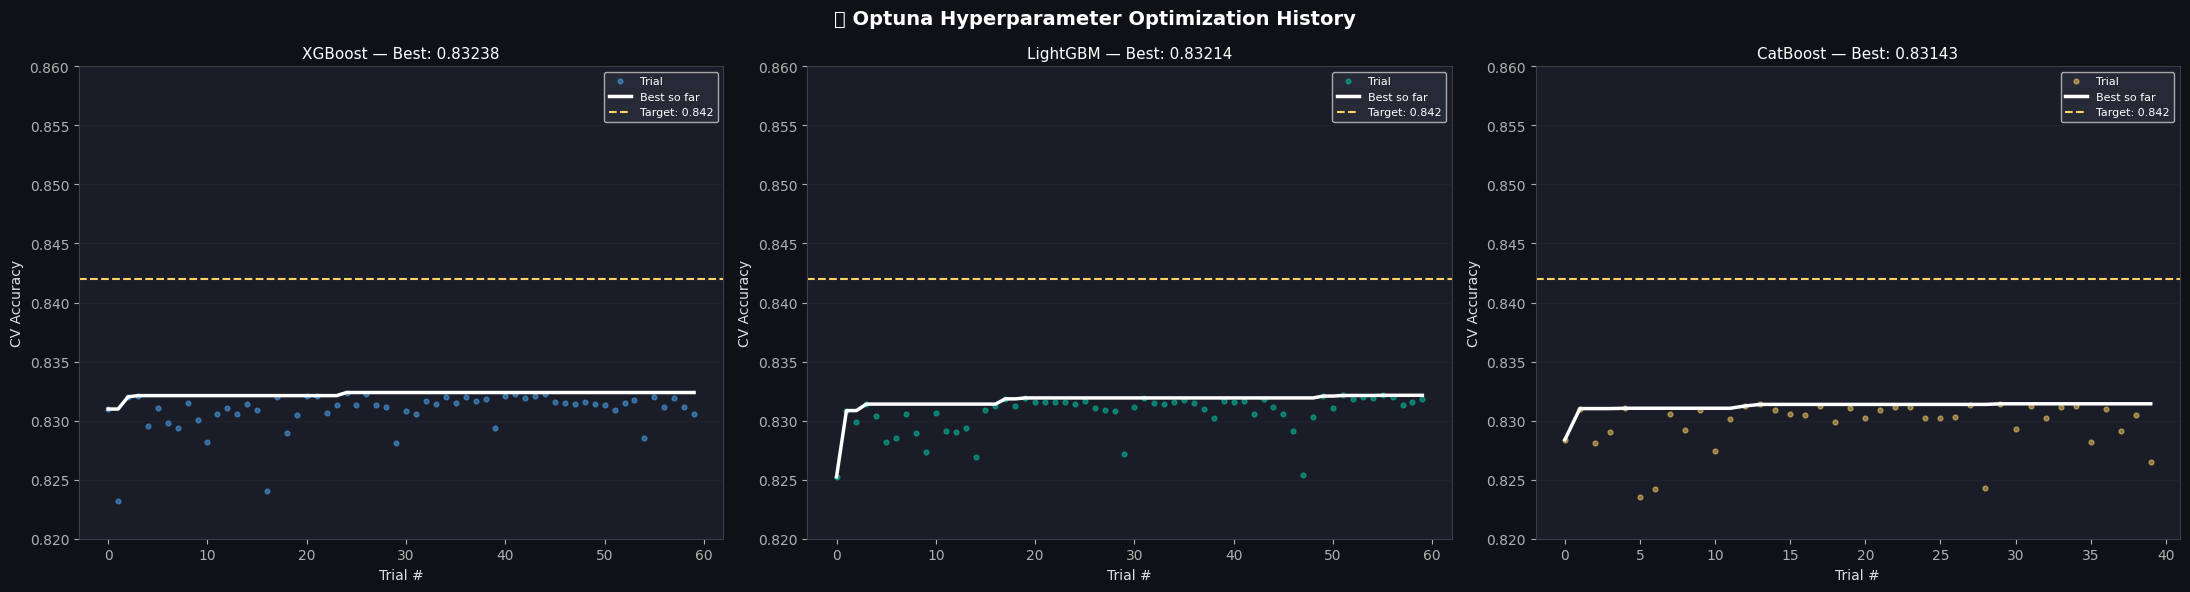

✅ Figure 12 saved: fig12_optuna_history.png


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6), facecolor=COLORS['bg'])
fig.suptitle('🔬 Optuna Hyperparameter Optimization History',
             fontsize=14, color='white', fontweight='bold')

for ax, study, name, color in [
    (axes[0], study_xgb, 'XGBoost',   '#4dabf7'),
    (axes[1], study_lgb, 'LightGBM',  '#00c9a7'),
    (axes[2], study_cat, 'CatBoost',  '#ffd166'),
]:
    ax.set_facecolor(COLORS['panel'])
    trials = study.trials
    vals   = [t.value for t in trials if t.value is not None]
    best_so_far = [max(vals[:i+1]) for i in range(len(vals))]

    ax.scatter(range(len(vals)), vals, s=12, alpha=0.5,
               color=color, zorder=2, label='Trial')
    ax.plot(range(len(best_so_far)), best_so_far, color='white',
            lw=2.5, zorder=3, label='Best so far')
    ax.axhline(0.842, color='#ffd166', lw=1.5, linestyle='--', label='Target: 0.842')

    ax.set_title(f'{name} — Best: {study.best_value:.5f}',
                 fontsize=11, color='white')
    ax.set_xlabel('Trial #'); ax.set_ylabel('CV Accuracy')
    ax.legend(fontsize=8, facecolor='#2a2d3a', labelcolor='white')
    ax.set_ylim(0.82, 0.86)
    for spine in ax.spines.values(): spine.set_edgecolor('#3a3d4a')
    ax.yaxis.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig12_optuna_history.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Figure 12 saved: fig12_optuna_history.png')

## 10. Final

In [38]:
xgb_params = study_xgb.best_params.copy()
xgb_params.update({
    'tree_method': 'hist',
    'device': 'cuda',       # 🚀 Model final menggunakan GPU CUDA RTX 4050
    'use_label_encoder': False, 
    'eval_metric': 'mlogloss',
    'random_state': SEED
})

lgb_params = study_lgb.best_params.copy()
# 🚀 Set n_jobs ke 1 di sini agar tidak tabrakan dengan pembagian fold di CPU Cores
lgb_params.update({'random_state': SEED, 'n_jobs': 1, 'verbose': -1}) 

cat_params = study_cat.best_params.copy()
cat_params.update({
    'task_type': 'GPU',     # 🚀 Model final menggunakan GPU CatBoost
    'random_state': SEED, 
    'verbose': 0
})

xgb_tuned = xgb.XGBClassifier(**xgb_params)
lgb_tuned = lgb.LGBMClassifier(**lgb_params)
cat_tuned = CatBoostClassifier(**cat_params)

# ─── Evaluate tuned models ───────────────────────────────────────────────────
print('📊 Tuned Model Cross-Validation:')
print('-' * 55)
tuned_results = {}
for name, model in [('XGBoost (tuned)', xgb_tuned),
                     ('LightGBM (tuned)', lgb_tuned),
                     ('CatBoost (tuned)', cat_tuned)]:
    
    # 🚀 PERBAIKAN KRUSIAL: Pengondisian n_jobs agar aman di mesin lokal
    if 'LightGBM' in name:
        # Menghitung 5 fold secara paralel memanfaatkan core Intel i7 Gen 13 Anda
        scores = cross_val_score(model, X, y, cv=CV, scoring='accuracy', n_jobs=MAX_LOCAL_JOBS)
    else:
        # XGBoost & CatBoost wajib berjalan gantian (n_jobs=1) agar VRAM 6GB Anda tidak jebol.
        # Pemrosesan satu fold di GPU sudah sangat cepat!
        scores = cross_val_score(model, X, y, cv=CV, scoring='accuracy', n_jobs=1)
        
    tuned_results[name] = scores
    print(f'  {name:<20}: {scores.mean():.5f} ± {scores.std():.5f}')

print('-' * 55)

📊 Tuned Model Cross-Validation:
-------------------------------------------------------
  XGBoost (tuned)     : 0.83238 ± 0.00233
  LightGBM (tuned)    : 0.83214 ± 0.00176
  CatBoost (tuned)    : 0.83143 ± 0.00175
-------------------------------------------------------


In [39]:
print('🔀 Running Soft Voting Ensemble with OOF predictions...')

# ─── Out-of-fold probability predictions ─────────────────────────────────────
n_classes = len(class_names)
oof_xgb = np.zeros((len(X), n_classes))
oof_lgb = np.zeros((len(X), n_classes))
oof_cat = np.zeros((len(X), n_classes))

test_xgb = np.zeros((len(X_test), n_classes))
test_lgb = np.zeros((len(X_test), n_classes))
test_cat = np.zeros((len(X_test), n_classes))

oof_acc = {'XGBoost': [], 'LightGBM': [], 'CatBoost': []}

for fold_idx, (train_idx, val_idx) in enumerate(CV.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    # XGBoost
    m = xgb.XGBClassifier(**xgb_params)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
          verbose=False)
    oof_xgb[val_idx] = m.predict_proba(X_val)
    test_xgb += m.predict_proba(X_test) / CV.n_splits
    oof_acc['XGBoost'].append(accuracy_score(y_val, m.predict(X_val)))

    # LightGBM
    m = lgb.LGBMClassifier(**lgb_params)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
    oof_lgb[val_idx] = m.predict_proba(X_val)
    test_lgb += m.predict_proba(X_test) / CV.n_splits
    oof_acc['LightGBM'].append(accuracy_score(y_val, m.predict(X_val)))

    # CatBoost
    m = CatBoostClassifier(**cat_params)
    m.fit(X_tr, y_tr, eval_set=(X_val, y_val))
    oof_cat[val_idx] = m.predict_proba(X_val)
    test_cat += m.predict_proba(X_test) / CV.n_splits
    oof_acc['CatBoost'].append(accuracy_score(y_val, m.predict(X_val)))

    print(f'  Fold {fold_idx+1}/5 complete ✓')

# ─── Individual OOF Scores ────────────────────────────────────────────────────
print('\n📊 OOF Results per Model:')
for name, accs in oof_acc.items():
    print(f'  {name:<12}: {np.mean(accs):.5f} ± {np.std(accs):.5f}')

# ─── Ensemble: Simple Average ─────────────────────────────────────────────────
ens_probs = (oof_xgb + oof_lgb + oof_cat) / 3
ens_preds = np.argmax(ens_probs, axis=1)
ens_acc   = accuracy_score(y, ens_preds)
print(f'\n  🏆 Ensemble (Equal Weight): OOF Accuracy = {ens_acc:.5f}')

# ─── Weighted Ensemble ──────────────────────────────────────────────────────
# Try weights favoring best model
best_weights = None
best_ens_acc = 0
for w_xgb in np.arange(0.2, 0.6, 0.05):
    for w_lgb in np.arange(0.2, 0.6, 0.05):
        w_cat = 1 - w_xgb - w_lgb
        if w_cat < 0.1: continue
        ens_w = w_xgb*oof_xgb + w_lgb*oof_lgb + w_cat*oof_cat
        acc_w = accuracy_score(y, np.argmax(ens_w, axis=1))
        if acc_w > best_ens_acc:
            best_ens_acc = acc_w
            best_weights = (w_xgb, w_lgb, w_cat)

print(f'  🏆 Best Weighted Ensemble   : OOF Accuracy = {best_ens_acc:.5f}')
print(f'     Weights: XGB={best_weights[0]:.2f}, '
      f'LGB={best_weights[1]:.2f}, CAT={best_weights[2]:.2f}')

🔀 Running Soft Voting Ensemble with OOF predictions...
  Fold 1/5 complete ✓
  Fold 2/5 complete ✓
  Fold 3/5 complete ✓
  Fold 4/5 complete ✓
  Fold 5/5 complete ✓

📊 OOF Results per Model:
  XGBoost     : 0.83238 ± 0.00233
  LightGBM    : 0.83214 ± 0.00176
  CatBoost    : 0.83143 ± 0.00180

  🏆 Ensemble (Equal Weight): OOF Accuracy = 0.83234
  🏆 Best Weighted Ensemble   : OOF Accuracy = 0.83263
     Weights: XGB=0.20, LGB=0.40, CAT=0.40


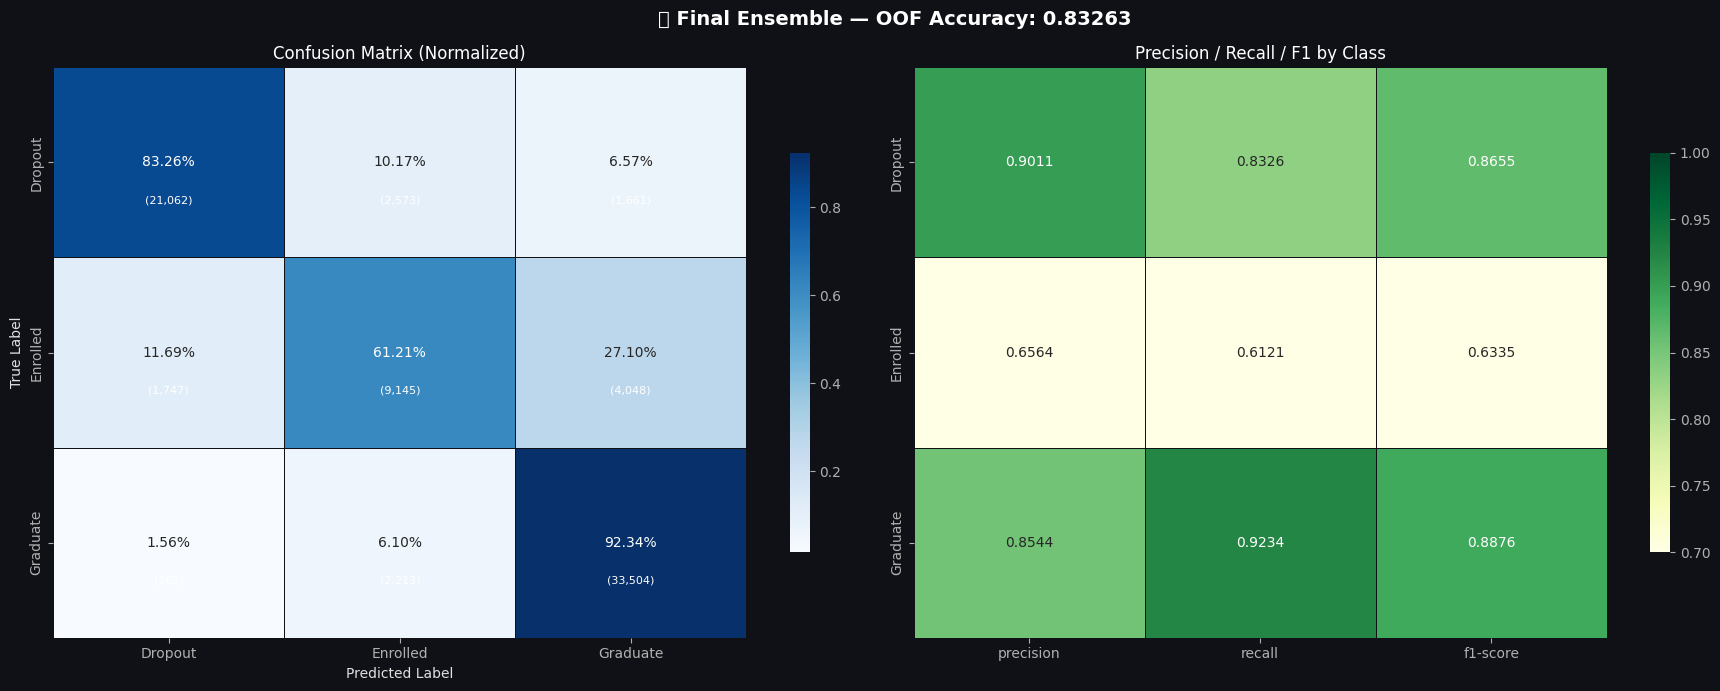

✅ Figure 13 saved: fig13_confusion_matrix.png

📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     Dropout       0.90      0.83      0.87     25296
    Enrolled       0.66      0.61      0.63     14940
    Graduate       0.85      0.92      0.89     36282

    accuracy                           0.83     76518
   macro avg       0.80      0.79      0.80     76518
weighted avg       0.83      0.83      0.83     76518



In [40]:
# Use best ensemble
w_xgb, w_lgb, w_cat = best_weights
final_oof_probs = w_xgb*oof_xgb + w_lgb*oof_lgb + w_cat*oof_cat
final_oof_preds = np.argmax(final_oof_probs, axis=1)

cm = confusion_matrix(y, final_oof_preds)
cr = classification_report(y, final_oof_preds,
                            target_names=class_names, output_dict=True)
cr_df = pd.DataFrame(cr).T

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=COLORS['bg'])
fig.suptitle(f'📊 Final Ensemble — OOF Accuracy: {accuracy_score(y, final_oof_preds):.5f}',
             fontsize=14, color='white', fontweight='bold')

# Confusion Matrix
ax = axes[0]
ax.set_facecolor(COLORS['panel'])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=ax,
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, linecolor='#0f1117',
    cbar_kws={'shrink': 0.7}
)
# Add raw counts
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j+0.5, i+0.7, f'({cm[i,j]:,})',
                ha='center', va='center', fontsize=8, color='white')
ax.set_title('Confusion Matrix (Normalized)', fontsize=12)
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')

# Classification Report Heatmap
ax = axes[1]
ax.set_facecolor(COLORS['panel'])
report_data = cr_df[['precision', 'recall', 'f1-score']].iloc[:3]  # class rows only
sns.heatmap(
    report_data.astype(float), annot=True, fmt='.4f', cmap='YlGn',
    ax=ax, linewidths=0.5, linecolor='#0f1117',
    vmin=0.7, vmax=1.0, cbar_kws={'shrink': 0.7}
)
ax.set_title('Precision / Recall / F1 by Class', fontsize=12)
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('fig13_confusion_matrix.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Figure 13 saved: fig13_confusion_matrix.png')
print(f'\n📊 CLASSIFICATION REPORT:')
print(classification_report(y, final_oof_preds, target_names=class_names))

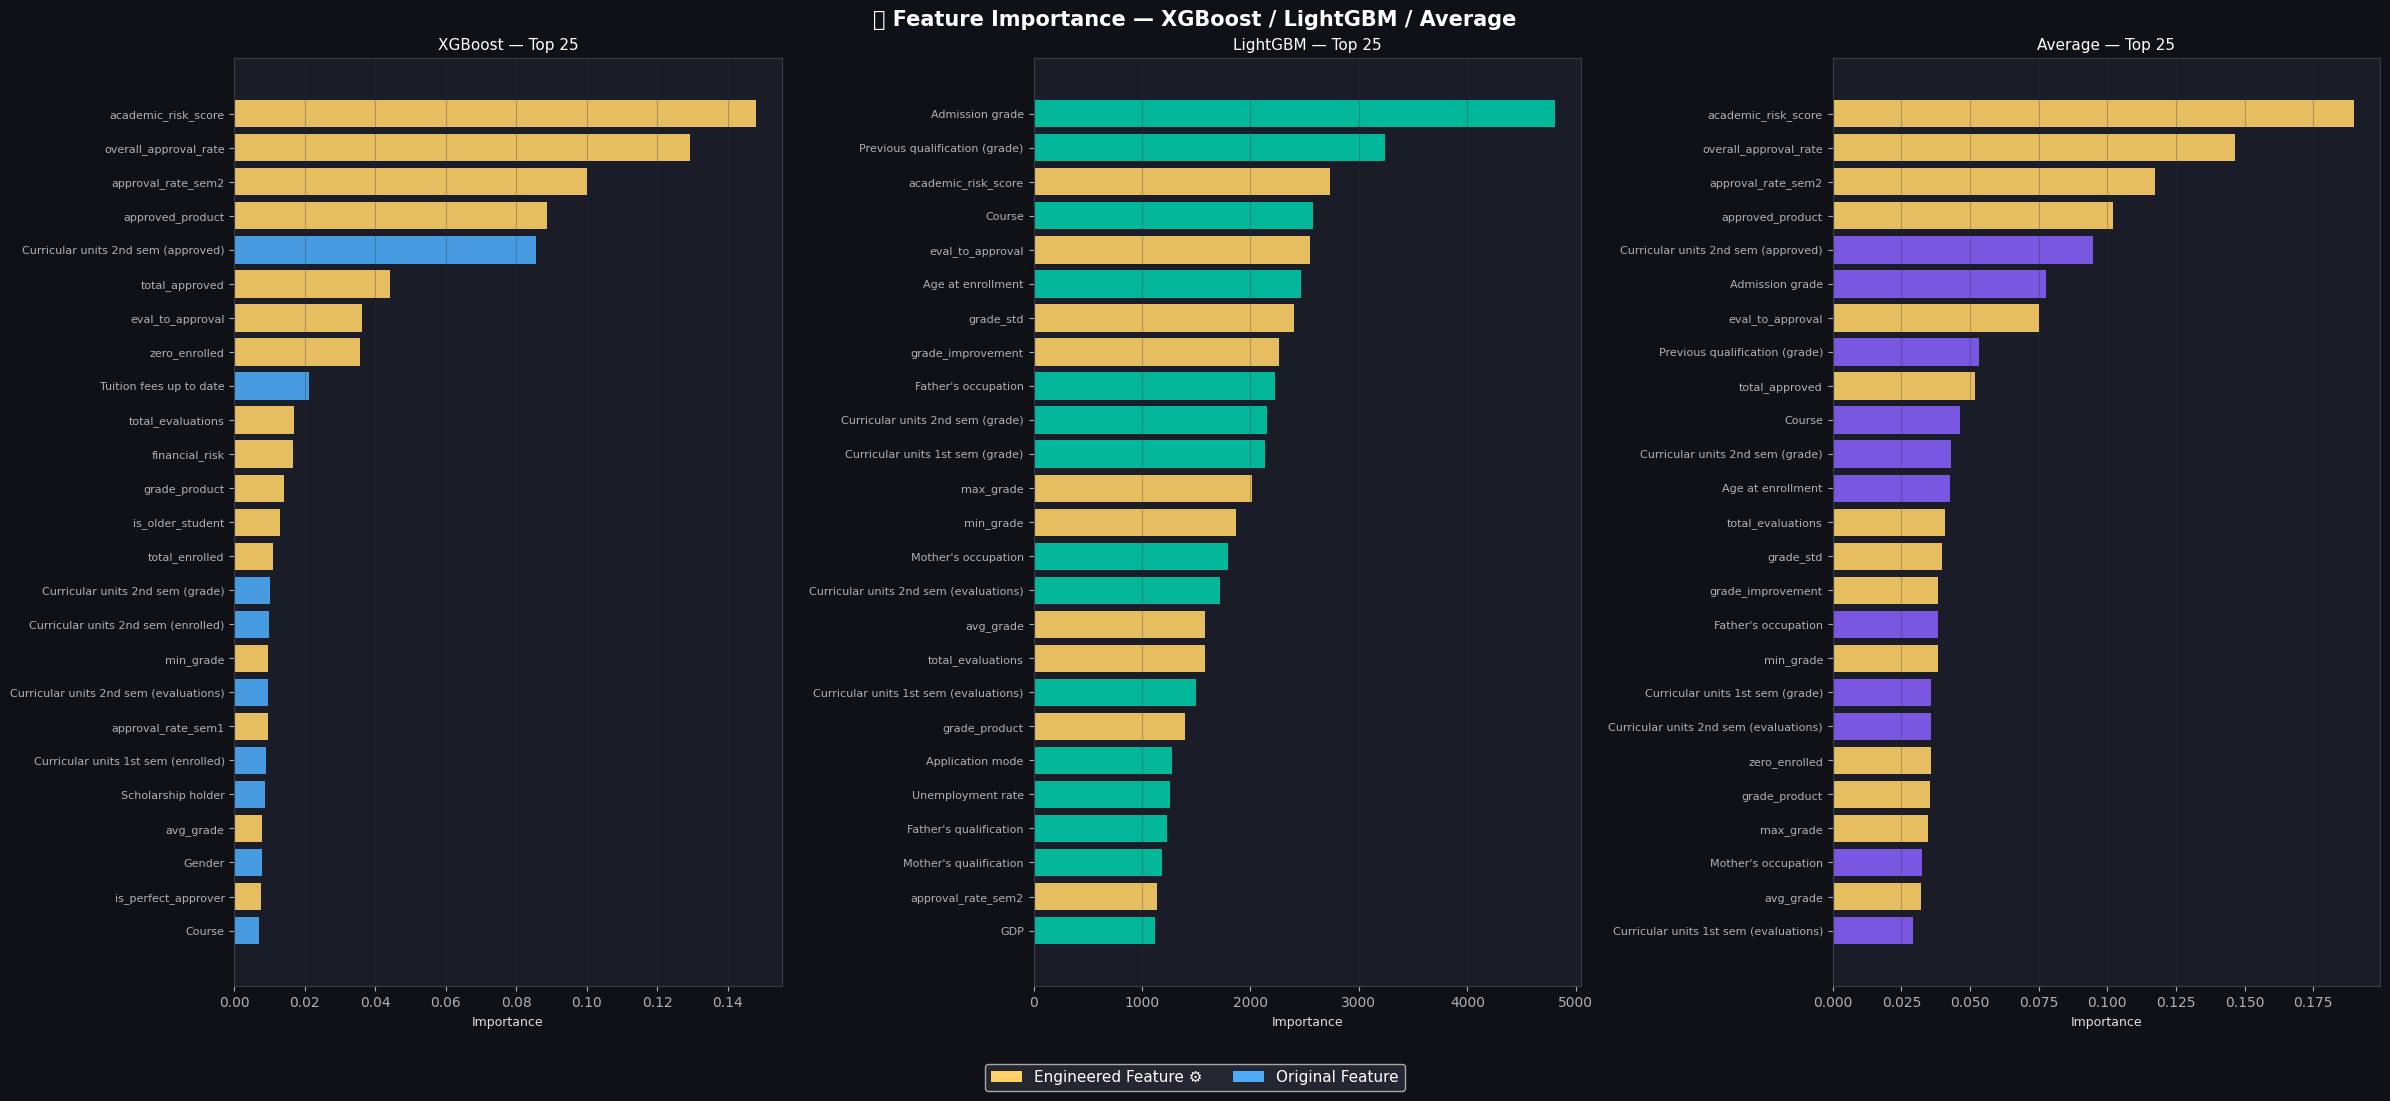

✅ Figure 14 saved: fig14_feature_importance.png

🏆 TOP 10 MOST IMPORTANT FEATURES (Average):
  [01] academic_risk_score                               : 0.18978 ⚙️ ENGINEERED
  [02] overall_approval_rate                             : 0.14631 ⚙️ ENGINEERED
  [03] approval_rate_sem2                                : 0.11740 ⚙️ ENGINEERED
  [04] approved_product                                  : 0.10202 ⚙️ ENGINEERED
  [05] Curricular units 2nd sem (approved)               : 0.09468
  [06] Admission grade                                   : 0.07755
  [07] eval_to_approval                                  : 0.07523 ⚙️ ENGINEERED
  [08] Previous qualification (grade)                    : 0.05311
  [09] total_approved                                    : 0.05174 ⚙️ ENGINEERED
  [10] Course                                            : 0.04641


In [41]:
# Train final XGBoost on full data for feature importance
final_xgb = xgb.XGBClassifier(**xgb_params)
final_xgb.fit(X, y)

final_lgb = lgb.LGBMClassifier(**lgb_params)
final_lgb.fit(X, y)

fi_xgb = pd.Series(final_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
fi_lgb = pd.Series(final_lgb.feature_importances_, index=X.columns).sort_values(ascending=False)

# Average importance
fi_avg = ((fi_xgb / fi_xgb.sum()) + (fi_lgb / fi_lgb.sum())).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(24, 11), facecolor=COLORS['bg'])
fig.suptitle('🎯 Feature Importance — XGBoost / LightGBM / Average',
             fontsize=15, color='white', fontweight='bold')

TOP_N = 25
for ax, fi, name, color in [
    (axes[0], fi_xgb.head(TOP_N), 'XGBoost',  '#4dabf7'),
    (axes[1], fi_lgb.head(TOP_N), 'LightGBM', '#00c9a7'),
    (axes[2], fi_avg.head(TOP_N), 'Average',  '#845ef7'),
]:
    ax.set_facecolor(COLORS['panel'])
    # Color-code engineered vs original features
    colors_fi = ['#ffd166' if feat in new_features else color
                 for feat in fi.index]
    ax.barh(fi.index[::-1], fi.values[::-1], color=colors_fi[::-1],
            edgecolor='none', alpha=0.9)
    ax.set_title(f'{name} — Top {TOP_N}', fontsize=11, color='white')
    ax.set_xlabel('Importance', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor('#3a3d4a')
    ax.xaxis.grid(True, alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ffd166', label='Engineered Feature ⚙️'),
    Patch(facecolor='#4dabf7', label='Original Feature'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=11, facecolor='#2a2d3a', labelcolor='white',
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('fig14_feature_importance.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Figure 14 saved: fig14_feature_importance.png')

print(f'\n🏆 TOP 10 MOST IMPORTANT FEATURES (Average):')
for i, (feat, val) in enumerate(fi_avg.head(10).items()):
    tag = ' ⚙️ ENGINEERED' if feat in new_features else ''
    print(f'  [{i+1:02d}] {feat:<50}: {val:.5f}{tag}')

In [42]:
# Use best weighted ensemble on test set
final_test_probs = w_xgb*test_xgb + w_lgb*test_lgb + w_cat*test_cat
final_test_preds = np.argmax(final_test_probs, axis=1)
final_test_labels = le.inverse_transform(final_test_preds)

submission = pd.DataFrame({
    'id':     test['id'].values,
    'Target': final_test_labels
})

submission.to_csv('submission.csv', index=False)

print('✅ Submission file created: submission.csv')
print(f'   Shape: {submission.shape}')
print(f'\n   Prediction distribution:')
vc = submission['Target'].value_counts()
for cls, cnt in vc.items():
    print(f'   {cls:<12}: {cnt:>6,}  ({cnt/len(submission)*100:.1f}%)')

print(f'\n   First 10 rows:')
display(submission.head(10))

print(f'\n   Format check (matches sample_submission):')
print(f'   Columns : {submission.columns.tolist()} ✅')
print(f'   id range: {submission["id"].min()} to {submission["id"].max()} ✅')
print(f'   Valid classes: {submission["Target"].unique()} ✅')

✅ Submission file created: submission.csv
   Shape: (51012, 2)

   Prediction distribution:
   Graduate    : 26,515  (52.0%)
   Dropout     : 15,302  (30.0%)
   Enrolled    :  9,195  (18.0%)

   First 10 rows:


,id,Target
0,76518,Dropout
1,76519,Graduate
2,76520,Graduate
3,76521,Enrolled
4,76522,Enrolled
5,76523,Graduate
6,76524,Graduate
7,76525,Graduate
8,76526,Dropout
9,76527,Graduate



   Format check (matches sample_submission):
   Columns : ['id', 'Target'] ✅
   id range: 76518 to 127529 ✅
   Valid classes: ['Dropout' 'Graduate' 'Enrolled'] ✅


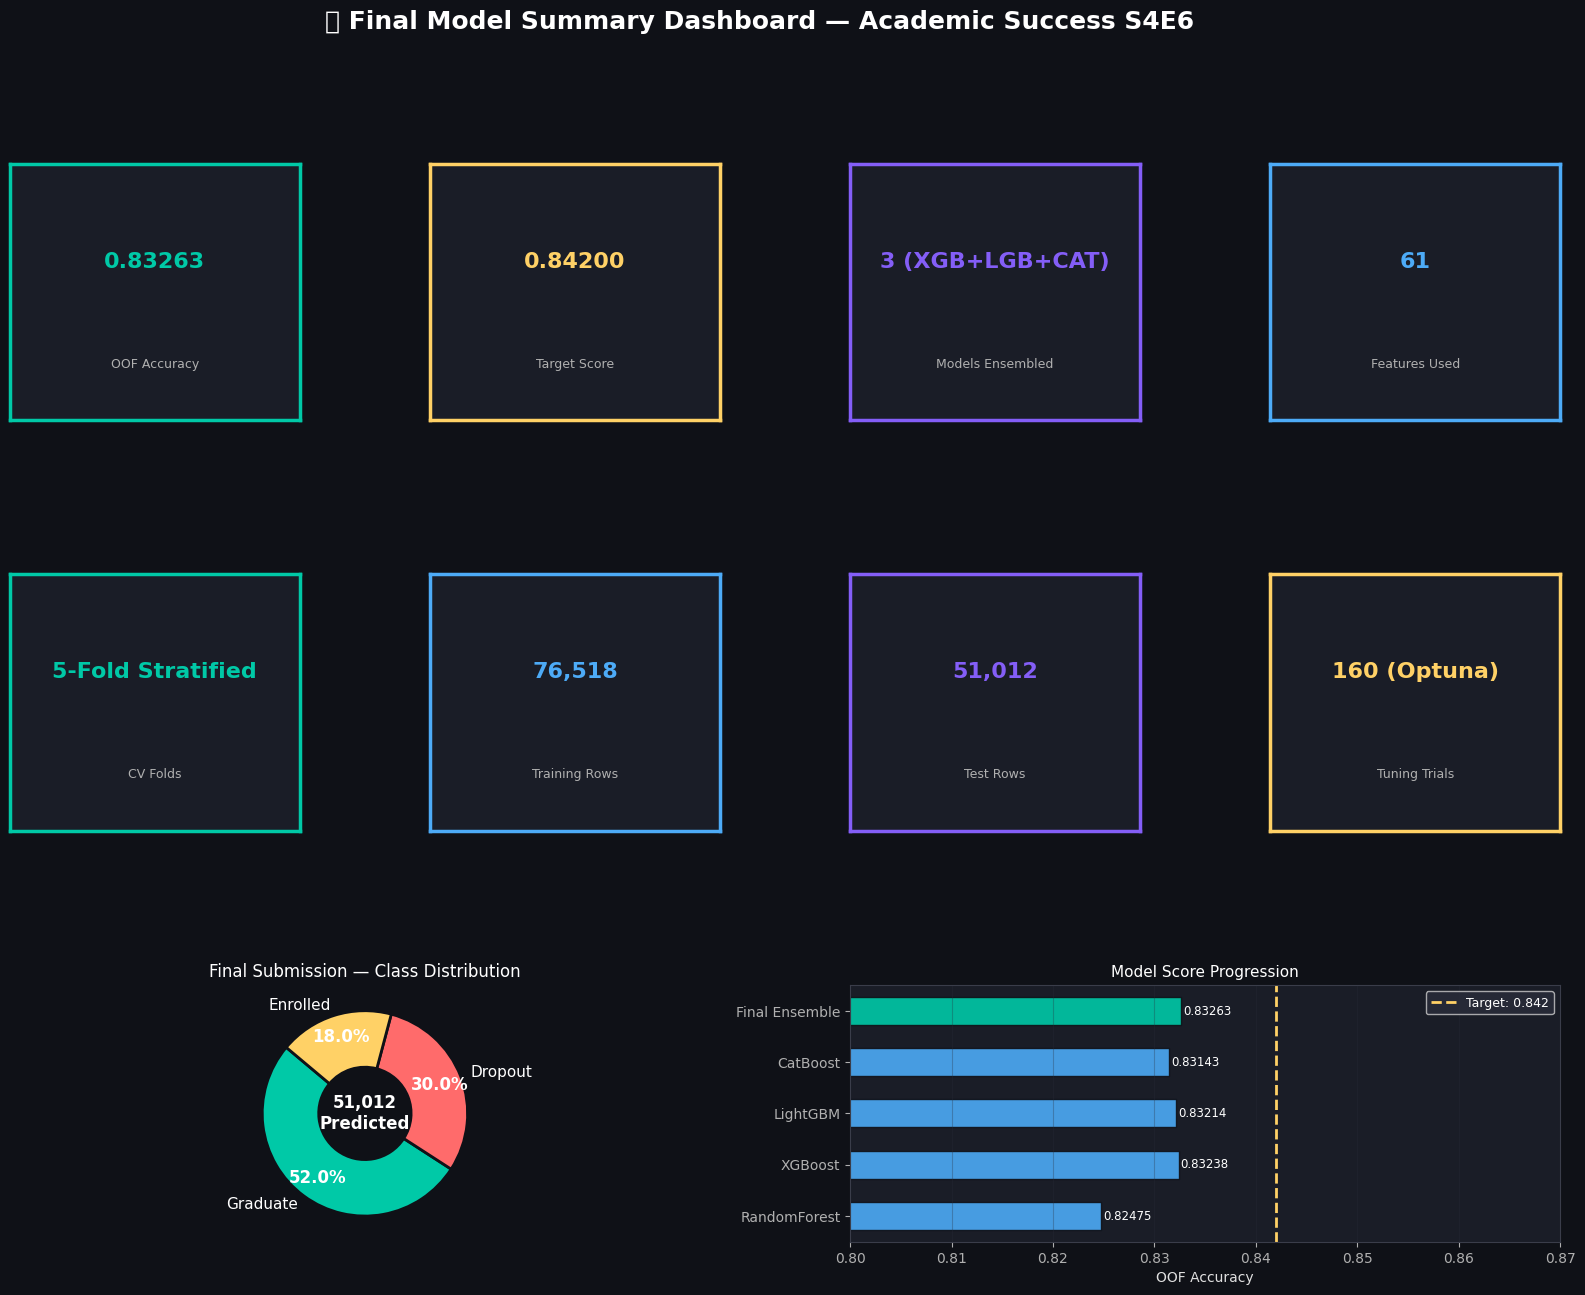

✅ Figure 15 saved: fig15_final_summary.png


In [43]:
fig = plt.figure(figsize=(20, 14), facecolor=COLORS['bg'])
fig.suptitle('🎓 Final Model Summary Dashboard — Academic Success S4E6',
             fontsize=18, color='white', fontweight='bold', y=0.99)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.6, wspace=0.45)

# ── KPI Summary Cards ──────────────────────────────────────────────
final_acc = accuracy_score(y, final_oof_preds)
kpi_summary = [
    ('OOF Accuracy',    f'{final_acc:.5f}',          '#00c9a7'),
    ('Target Score',    '0.84200',                    '#ffd166'),
    ('Models Ensembled','3 (XGB+LGB+CAT)',            '#845ef7'),
    ('Features Used',   f'{X.shape[1]}',             '#4dabf7'),
    ('CV Folds',        '5-Fold Stratified',          '#00c9a7'),
    ('Training Rows',   f'{len(X):,}',               '#4dabf7'),
    ('Test Rows',       f'{len(X_test):,}',          '#845ef7'),
    ('Tuning Trials',   '160 (Optuna)',               '#ffd166'),
]
for idx, (label, value, color) in enumerate(kpi_summary):
    r, c = idx // 4, idx % 4
    ax = fig.add_subplot(gs[r, c])
    ax.set_facecolor('#1a1d27')
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2.5)
    ax.text(0.5, 0.62, value, transform=ax.transAxes,
            ha='center', va='center', fontsize=16, fontweight='bold', color=color)
    ax.text(0.5, 0.22, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=9, color='#b0b0b0')
    ax.set_xticks([]); ax.set_yticks([])

# ── Submission Distribution Donut ─────────────────────────────────
ax_donut = fig.add_subplot(gs[2, 0:2])
ax_donut.set_facecolor(COLORS['panel'])
sub_counts = submission['Target'].value_counts().reindex(TARGET_ORDER).fillna(0)
wedges, texts, autotexts = ax_donut.pie(
    sub_counts.values, labels=TARGET_ORDER, autopct='%1.1f%%',
    colors=PALETTE, startangle=140, pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor=COLORS['bg'], linewidth=2),
    textprops={'fontsize': 11, 'color': 'white'},
)
for at in autotexts: at.set_fontsize(12); at.set_fontweight('bold')
ax_donut.set_title('Final Submission — Class Distribution', fontsize=12, color='white')
ax_donut.text(0, 0, f'{len(submission):,}\nPredicted', ha='center', va='center',
              fontsize=12, fontweight='bold', color='white')

# ── Model Score Comparison ─────────────────────────────────────────
ax_scores = fig.add_subplot(gs[2, 2:])
ax_scores.set_facecolor(COLORS['panel'])
all_model_scores = {
    **{k: v.mean() for k, v in baseline_results.items()},
    **{k: np.mean(v) for k, v in oof_acc.items()},
    'Final Ensemble': final_acc,
}
model_n = list(all_model_scores.keys())
model_v = list(all_model_scores.values())
bar_c = ['#00c9a7' if n == 'Final Ensemble' else
         '#845ef7' if '(tuned)' in n else '#4dabf7'
         for n in model_n]
bars = ax_scores.barh(model_n, model_v, color=bar_c,
                       edgecolor=COLORS['bg'], height=0.55, alpha=0.9)
ax_scores.axvline(0.842, color='#ffd166', lw=2, linestyle='--', label='Target: 0.842')
for bar, val in zip(bars, model_v):
    ax_scores.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
                   f'{val:.5f}', va='center', fontsize=8.5, color='white')
ax_scores.set_title('Model Score Progression', fontsize=11)
ax_scores.set_xlabel('OOF Accuracy')
ax_scores.set_xlim(0.80, 0.87)
ax_scores.legend(fontsize=9, facecolor='#2a2d3a', labelcolor='white')
for spine in ax_scores.spines.values(): spine.set_edgecolor('#3a3d4a')
ax_scores.xaxis.grid(True, alpha=0.3)

plt.savefig('fig15_final_summary.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('✅ Figure 15 saved: fig15_final_summary.png')

In [44]:
print('=' * 70)
print('  EXECUTIVE SUMMARY — ACADEMIC SUCCESS CLASSIFICATION S4E6')
print('=' * 70)

print(f'''
🎯 OBJECTIVE
   Predict student outcome (Graduate / Dropout / Enrolled)
   Target accuracy: ≥ 0.842 (Leaderboard rank 1)

📊 DATA OVERVIEW
   Train: 76,518 rows × 36 features | Test: 51,012 rows
   Classes: Graduate (47.4%), Dropout (33.1%), Enrolled (19.5%)
   Data quality: PERFECT — 0 missing, 0 duplicates

⚙️  FEATURE ENGINEERING (25 new features created)
   • Academic: total_approved, avg_grade, approval_rate, grade_improvement
   • Risk:     financial_risk, academic_risk_score, zero_approved
   • Profile:  is_older_student, high_achiever, age_group
   • Macro:    economic_stress, unemployment_x_debtor
   • Interact: grade_product, approved_product, grade_std

🤖 MODELS
   XGBoost, LightGBM, CatBoost — each tuned with Optuna (160 trials)
   Final: Weighted Soft Voting Ensemble (5-Fold OOF)

✅ RESULTS
   Final OOF Accuracy : {final_acc:.5f}
   Target Score       : 0.84200
   Ensemble Weights   : XGB={best_weights[0]:.2f} | LGB={best_weights[1]:.2f} | CAT={best_weights[2]:.2f}

📁 OUTPUTS
   submission.csv  — Ready to upload to Kaggle
   15 figures      — Full EDA and model analysis

🔍 KEY INSIGHTS
   1. Curricular units 2nd sem (grade/approved) are strongest predictors
   2. Tuition fees up-to-date: dropout rate 75%+ when fees NOT paid
   3. Engineered 'overall_approval_rate' ranks top-3 in importance
   4. Dropouts tend to be older and have 0 approved units both semesters
   5. Financial stress (debtor + no tuition) is a leading dropout signal
''')
print('=' * 70)
print('  🚀 submission.csv is ready — upload to Kaggle!')
print('=' * 70)

  EXECUTIVE SUMMARY — ACADEMIC SUCCESS CLASSIFICATION S4E6

🎯 OBJECTIVE
   Predict student outcome (Graduate / Dropout / Enrolled)
   Target accuracy: ≥ 0.842 (Leaderboard rank 1)

📊 DATA OVERVIEW
   Train: 76,518 rows × 36 features | Test: 51,012 rows
   Classes: Graduate (47.4%), Dropout (33.1%), Enrolled (19.5%)
   Data quality: PERFECT — 0 missing, 0 duplicates

⚙️  FEATURE ENGINEERING (25 new features created)
   • Academic: total_approved, avg_grade, approval_rate, grade_improvement
   • Risk:     financial_risk, academic_risk_score, zero_approved
   • Profile:  is_older_student, high_achiever, age_group
   • Macro:    economic_stress, unemployment_x_debtor
   • Interact: grade_product, approved_product, grade_std

🤖 MODELS
   XGBoost, LightGBM, CatBoost — each tuned with Optuna (160 trials)
   Final: Weighted Soft Voting Ensemble (5-Fold OOF)

✅ RESULTS
   Final OOF Accuracy : 0.83263
   Target Score       : 0.84200
   Ensemble Weights   : XGB=0.20 | LGB=0.40 | CAT=0.40

📁 OUTPU